In [1]:
import logging
from tmu.models.classification.vanilla_classifier import TMClassifier
import os
import config
import pickle
import numpy as np
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_otsu_thresholding_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, build_save_path, load_raw_maps_and_plot_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-10 21:31:26,447 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-05-10 21:31:26,454 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-05-10 21:31:26,468 - matplotlib - DEBUG - interactive is False
2026-05-10 21:31:26,469 - matplotlib - DEBUG - platform is linux
2026-05-10 21:31:26,525 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-05-10 21:31:26,527 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.OTSU
CURRENT_DATASET = config.BLOODMNIST
CURRENT_RESOLUTION = 1 
specialist_name = "Otsu"
channel_names = [f"{specialist_name} - {c}" for c in ["Red", "Green", "Blue"]]

In [3]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [4]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_otsu_thresholding_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test)

In [5]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)
Y_val = Y_val.astype(np.uint32)

In [6]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="f1_macro")

[I 2026-03-14 19:34:07,009] A new study created in memory with name: no-name-36db8481-76ec-40cf-a15e-978460662e63


[I 2026-03-14 22:17:10,881] Trial 0 finished with value: 0.7818058910590653 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7818058910590653.


[I 2026-03-15 00:56:06,699] Trial 1 finished with value: 0.6972727925394806 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7818058910590653.


[I 2026-03-15 04:04:46,656] Trial 2 finished with value: 0.8134236897621085 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.8134236897621085.


[I 2026-03-15 07:00:40,648] Trial 3 finished with value: 0.8149723697998608 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 3 with value: 0.8149723697998608.


...

[I 2026-03-20 03:11:24,892] Trial 46 finished with value: 0.7931226750281235 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 41 with value: 0.8337140047590987.


[I 2026-03-20 05:48:43,477] Trial 47 finished with value: 0.8022751510833384 and parameters: {'s': 9.0, 'T': 2500, 'patch_size': 9, 'max_included_literals': 64}. Best is trial 41 with value: 0.8337140047590987.


[I 2026-03-20 08:19:27,238] Trial 48 finished with value: 0.8151492916297224 and parameters: {'s': 8.0, 'T': 1500, 'patch_size': 7, 'max_included_literals': 512}. Best is trial 41 with value: 0.8337140047590987.


[I 2026-03-20 10:37:04,725] Trial 49 finished with value: 0.8099725224535297 and parameters: {'s': 11.0, 'T': 5000, 'patch_size': 5, 'max_included_literals': 64}. Best is trial 41 with value: 0.8337140047590987.


Best f1_macro: 0.8337140047590987
Best hyperparameters: {'s': 13.0, 'T': 3500, 'patch_size': 9, 'max_included_literals': 64}


In [7]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/otsu.json")

Best F1 score macro accuracy: 0.8337140047590987
Best hyperparameters: {'s': 13.0, 'T': 3500, 'patch_size': 9, 'max_included_literals': 64}
Best Optuna results saved to hyperparameters/otsu.json


In [6]:
best_value, best_params = load_optuna_best_results("hyperparameters/otsu.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [9]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="BloodMNIST_Otsu",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 70.45% (509.08s)


#2 Accuracy: 76.32% (463.43s)


#3 Accuracy: 76.53% (451.89s)


#4 Accuracy: 78.98% (449.67s)


...

#96 Accuracy: 83.57% (372.48s)


#97 Accuracy: 83.86% (378.38s)


#98 Accuracy: 83.05% (372.32s)


#99 Accuracy: 83.63% (371.59s)


#100 Accuracy: 83.28% (371.86s)


In [7]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BloodMNIST_Otsu_Specialist.pkl")

In [11]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [8]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

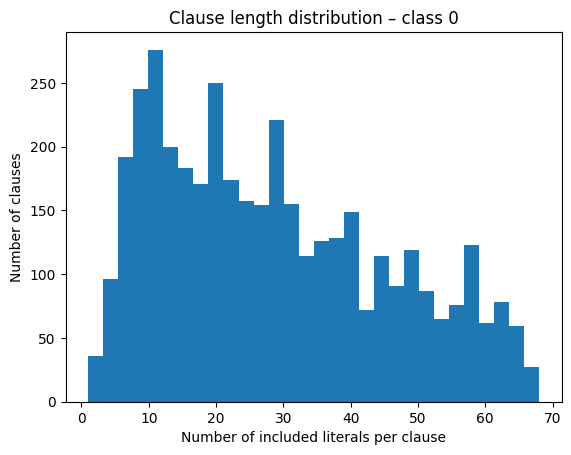

Class 0: median=26.0, mean=28.6, std=17.1


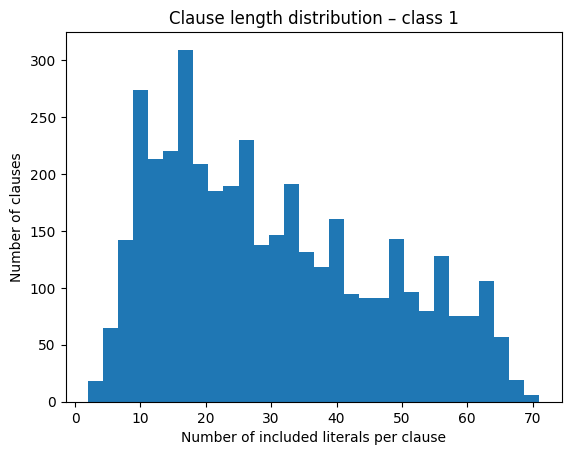

Class 1: median=27.0, mean=30.2, std=16.7


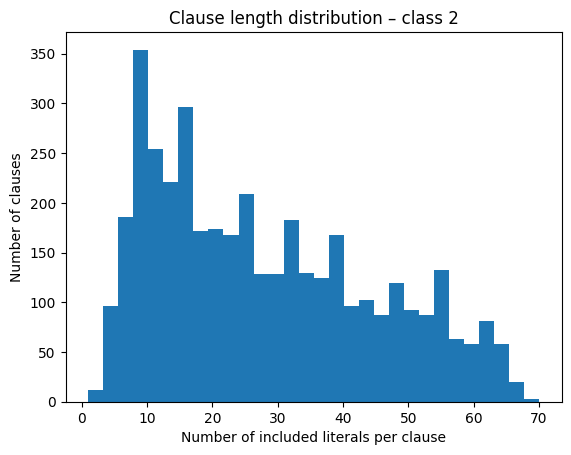

Class 2: median=24.0, mean=28.0, std=16.8


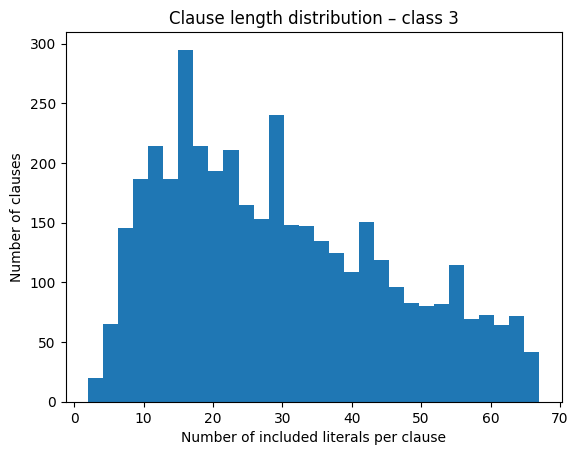

Class 3: median=27.0, mean=29.6, std=16.1


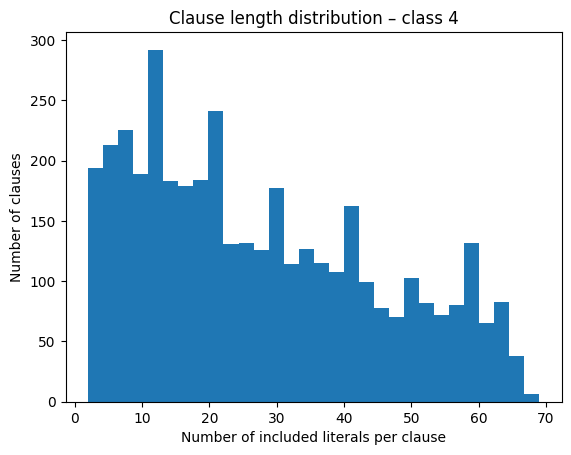

Class 4: median=24.0, mean=27.5, std=17.8


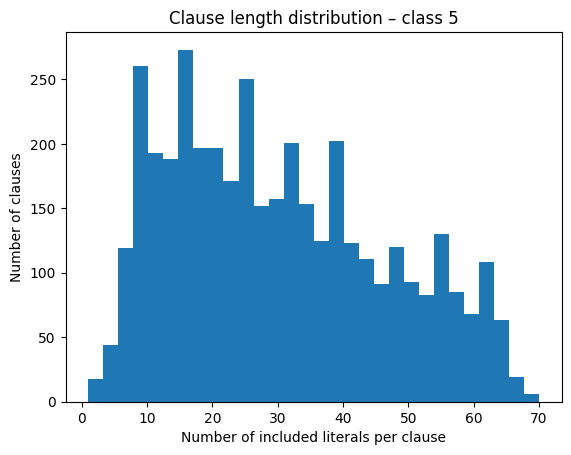

Class 5: median=28.0, mean=30.2, std=16.4


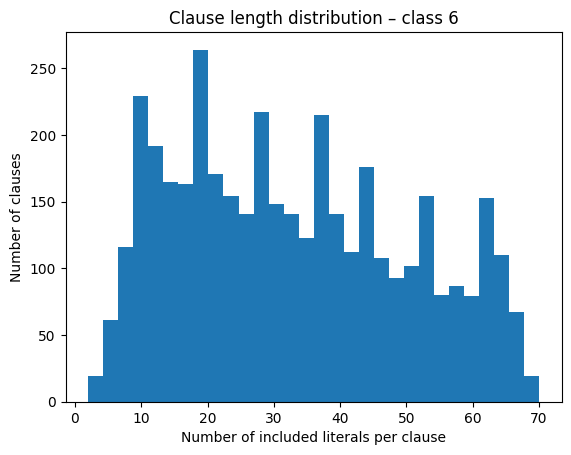

Class 6: median=31.0, mean=32.9, std=17.3


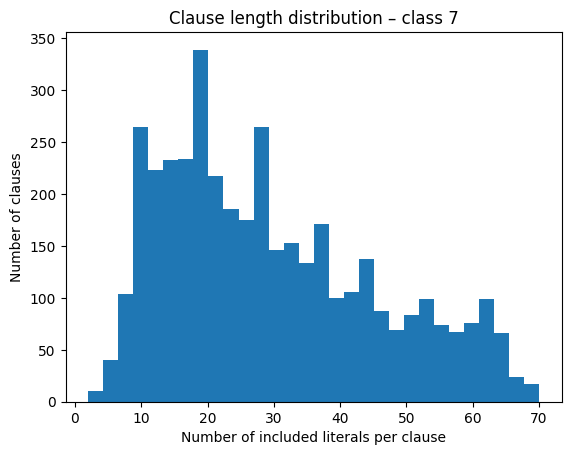

Class 7: median=26.0, mean=29.6, std=16.0


In [14]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 83.28%
2026-05-10 21:32:15,244 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 21:32:15,247 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 21:32:15,270 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x725230b62cc0>


Saved to saved_confusion_matrices/blood_otsu.svg


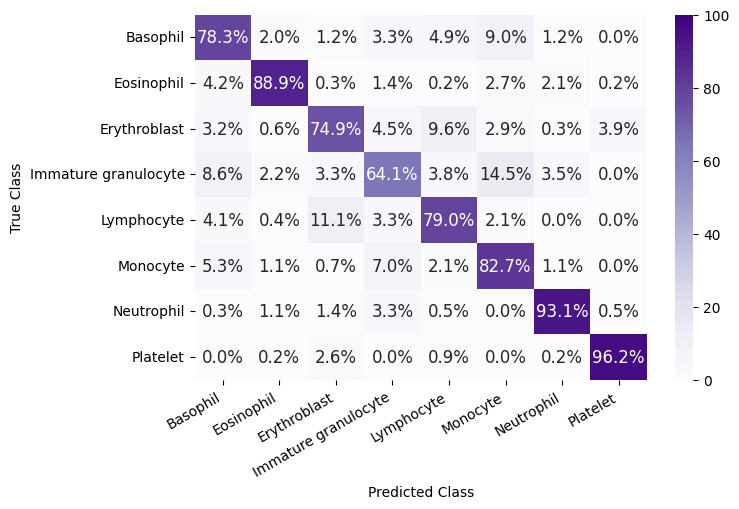

In [7]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="BloodMNIST_Otsu", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, rotate_xlabels=True, figsize=(7.8, 5.2), cmap = "Purples") 

# Class 0 Local Examples 

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 3263
True class: 0
Predicted class: 0
Selected image index: 1268
True class: 0
Predicted class: 0
Selected image index: 2120
True class: 0
Predicted class: 0


0
2026-04-10 15:53:34,179 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 15:53:34,183 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 3263  |  predicted class: 0
2026-04-10 15:53:34,217 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc8009b0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c0_s3263_aggr.svg


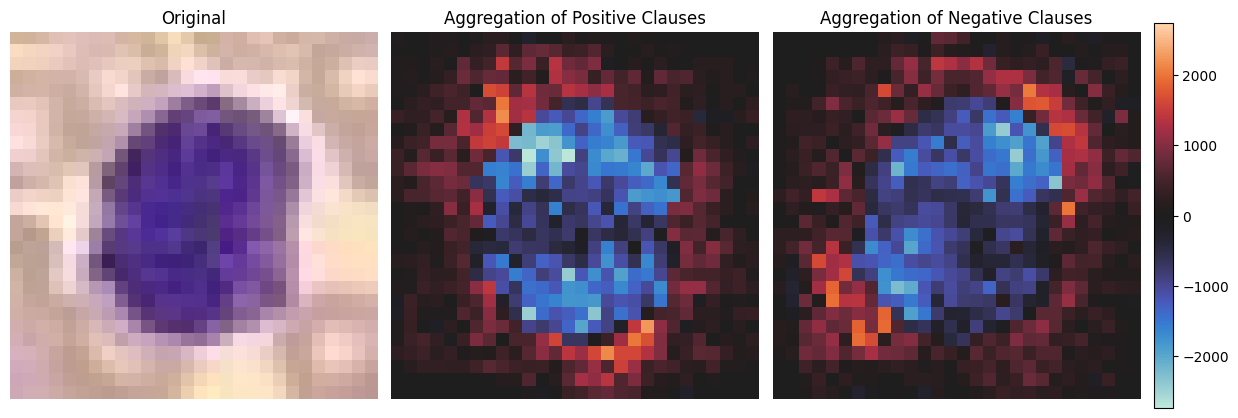

Visualizing sample 3263  |  predicted class: 0
2026-04-10 15:53:38,222 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc7f90a0>
2026-04-10 15:53:38,249 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1c0b3d3080>
2026-04-10 15:53:38,277 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc6b0110>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c0_s3263_chan.svg


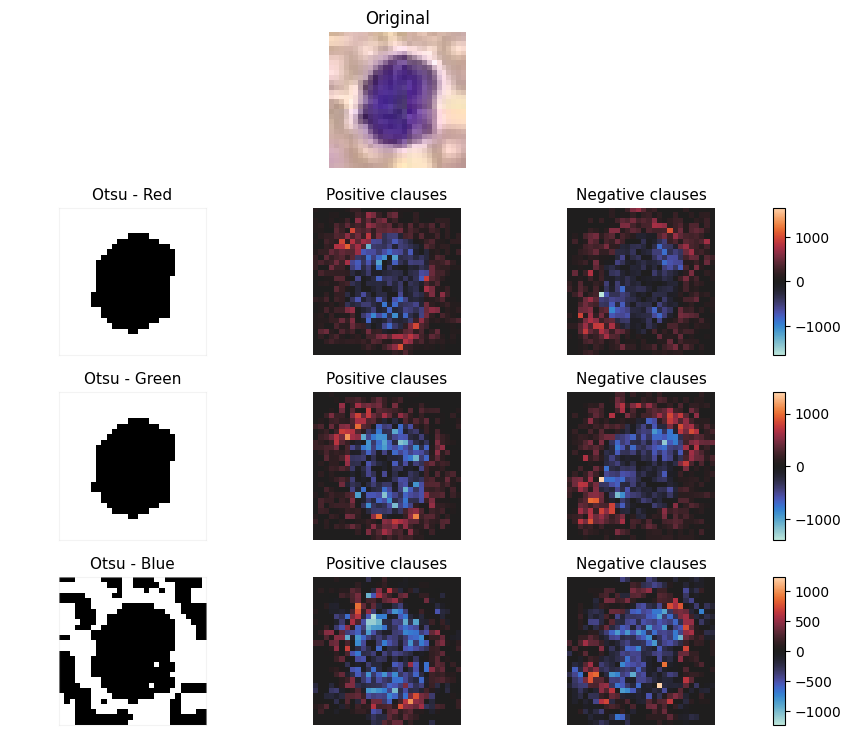

In [10]:
image_index =  3263
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

0
Visualizing sample 1268  |  predicted class: 0
2026-04-10 15:53:42,367 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf7b652b0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c0_s1268_aggr.svg


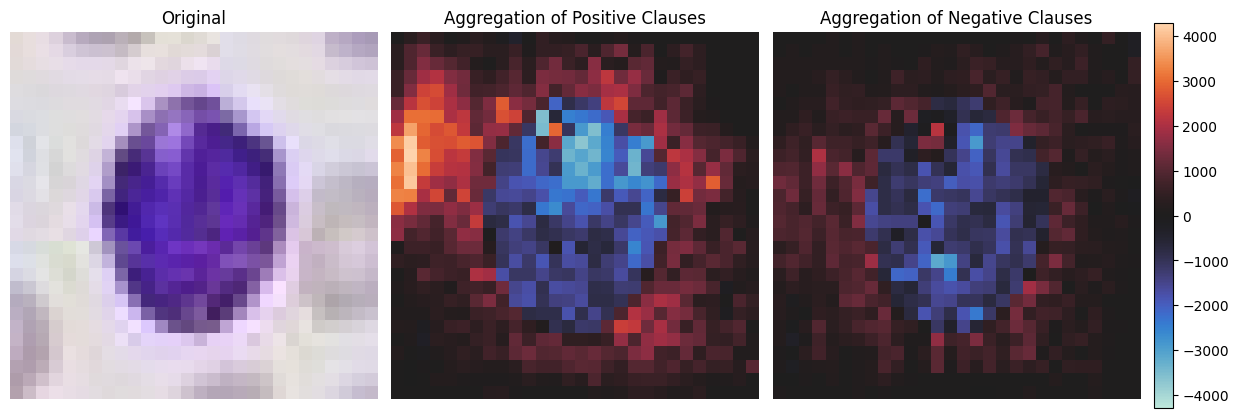

Visualizing sample 1268  |  predicted class: 0
2026-04-10 15:53:46,276 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf721be90>
2026-04-10 15:53:46,305 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf7ad1310>
2026-04-10 15:53:46,333 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1beba21bb0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c0_s1268_chan.svg


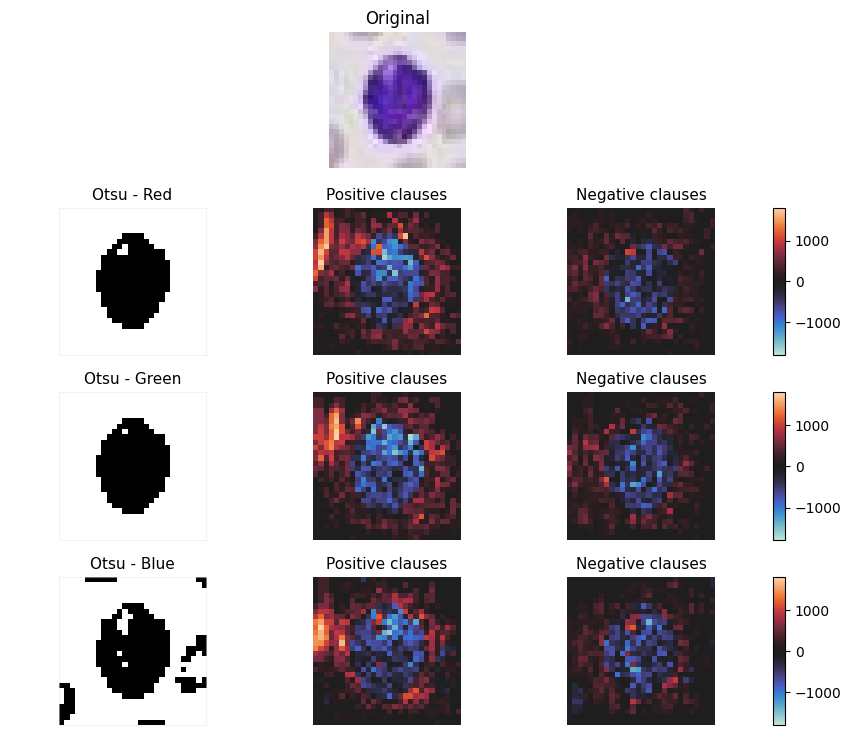

In [11]:
image_index =  1268
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

0


Visualizing sample 2120  |  predicted class: 0
2026-04-10 15:53:50,598 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be8922210>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c0_s2120_aggr.svg


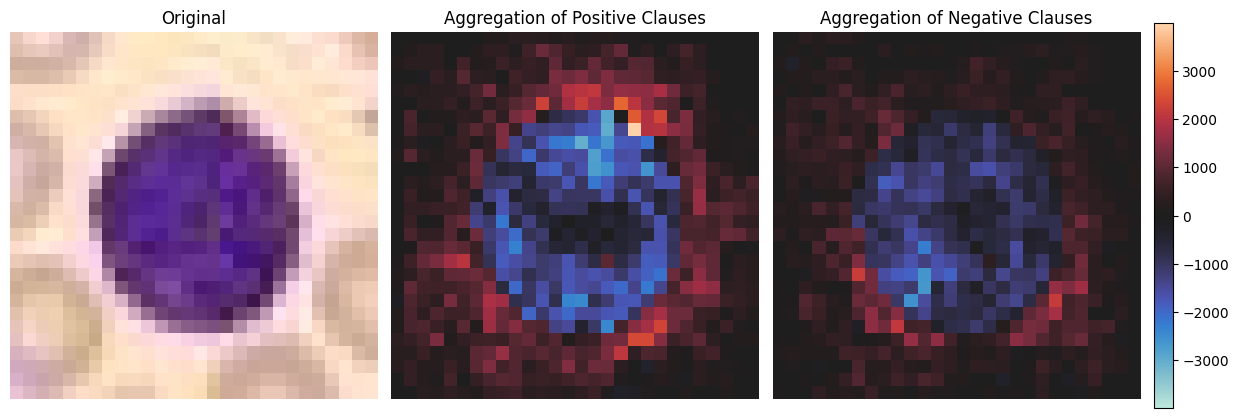

Visualizing sample 2120  |  predicted class: 0
2026-04-10 15:53:54,544 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be88383e0>
2026-04-10 15:53:54,572 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be881cbf0>
2026-04-10 15:53:54,599 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1beba82a80>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c0_s2120_chan.svg


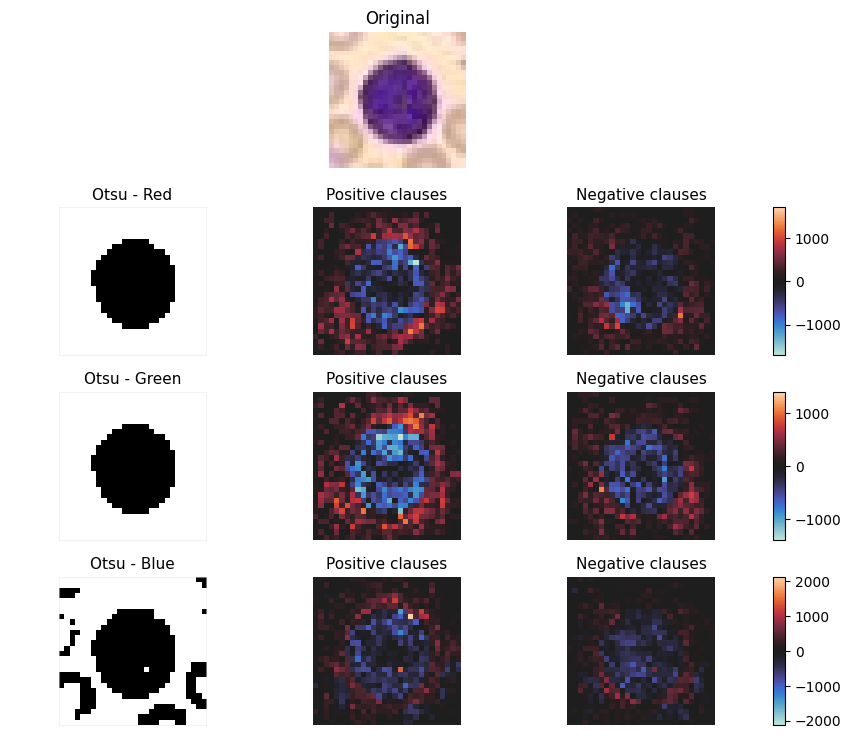

In [12]:
image_index =  2120
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 1 Local Examples 

In [13]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

1
2026-04-15 11:42:50,786 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-15 11:42:50,789 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 2443  |  predicted class: 1
2026-04-15 11:42:50,821 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7559cb5bd700>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c1_s2443_aggr.svg


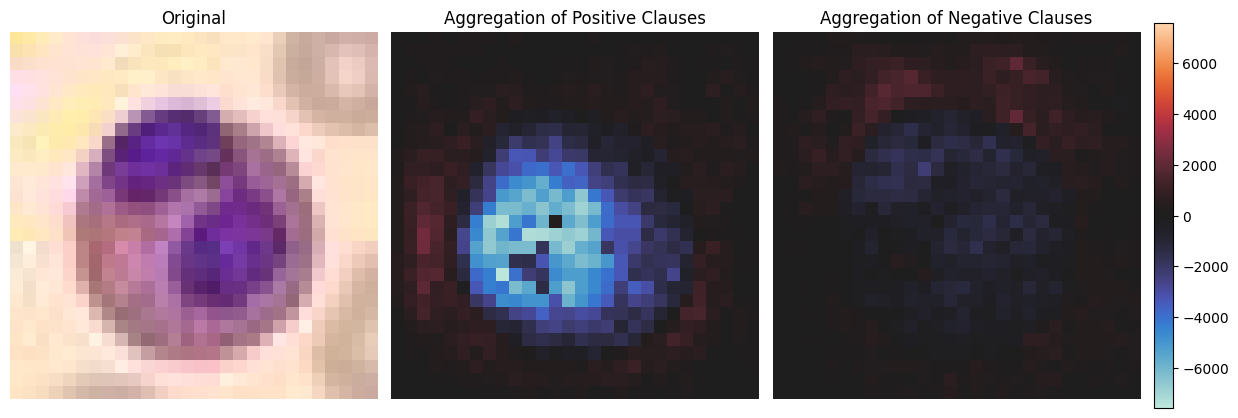

Visualizing sample 2443  |  predicted class: 1
2026-04-15 11:42:54,659 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7559d8eb0bc0>
2026-04-15 11:42:54,686 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7559cb552570>
2026-04-15 11:42:54,714 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7559cb3fbe00>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c1_s2443_chan.svg


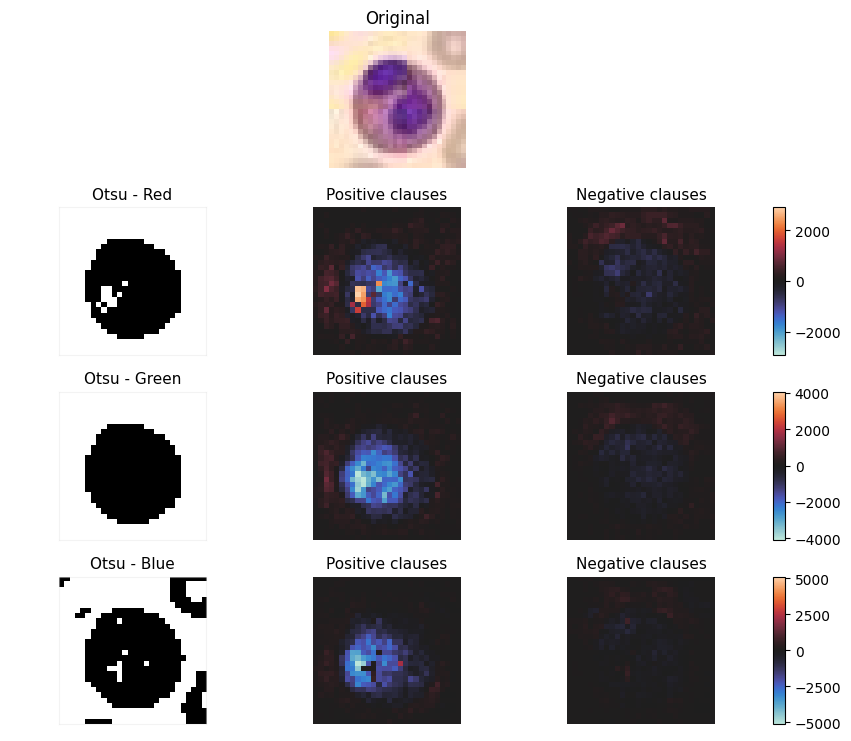

In [10]:
image_index =  2443
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

1
Visualizing sample 2459  |  predicted class: 1
2026-04-10 15:54:08,648 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1c02b253d0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c1_s2459_aggr.svg


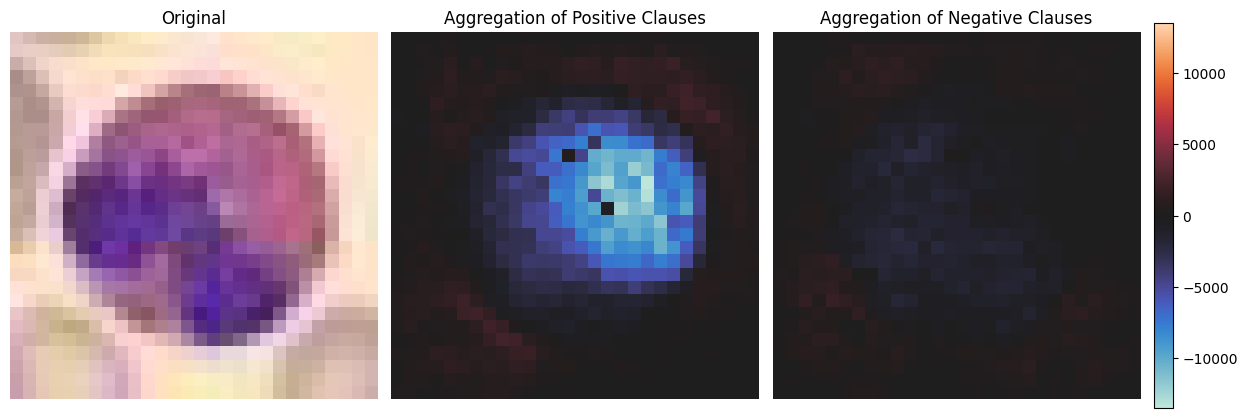

Visualizing sample 2459  |  predicted class: 1
2026-04-10 15:54:13,294 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be8727830>
2026-04-10 15:54:13,523 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc6a7260>
2026-04-10 15:54:13,554 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf71ac9e0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c1_s2459_chan.svg


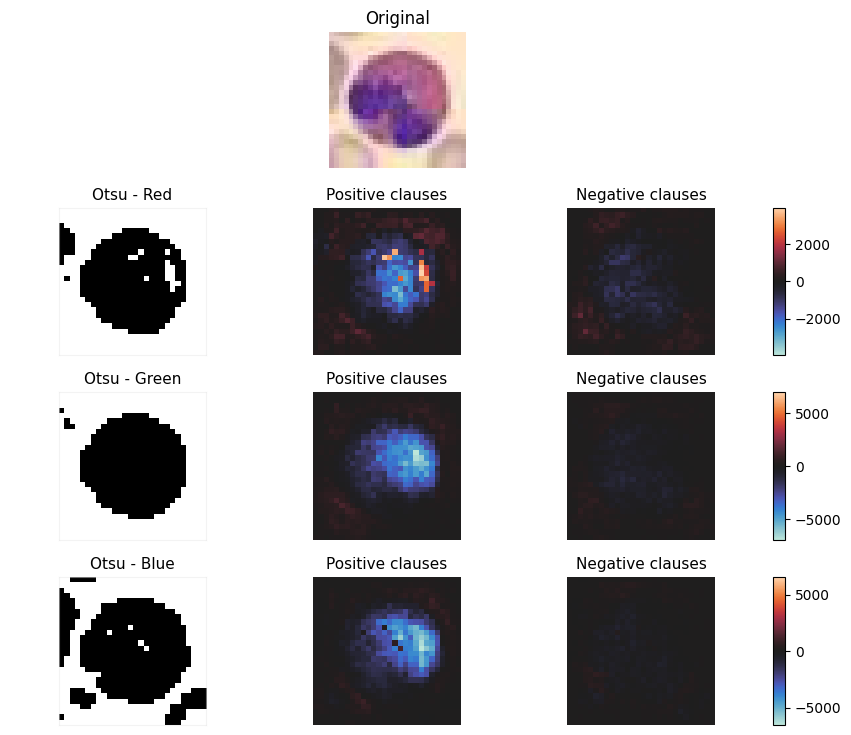

In [15]:
image_index =  2459
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

1
Visualizing sample 1078  |  predicted class: 1
2026-04-10 15:54:18,099 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1c02b24230>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c1_s1078_aggr.svg


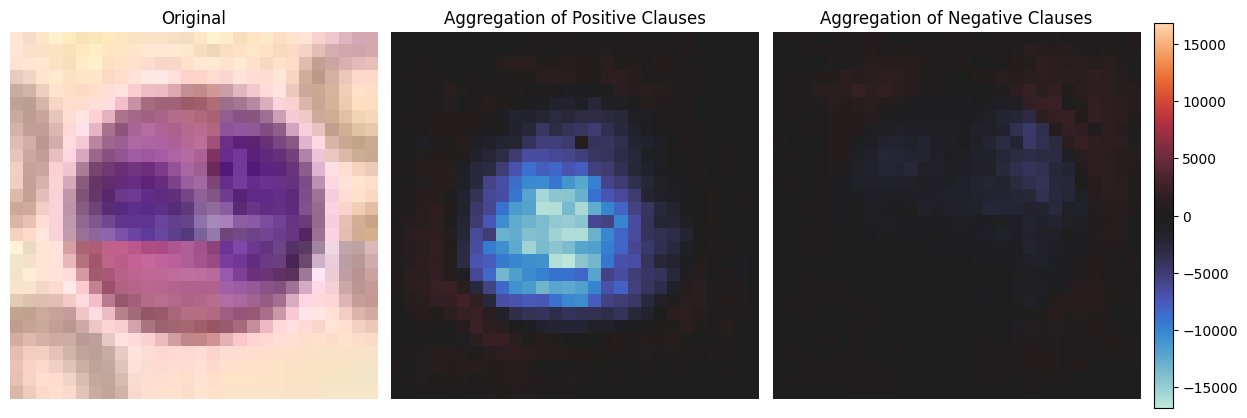

Visualizing sample 1078  |  predicted class: 1
2026-04-10 15:54:22,424 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc6964e0>
2026-04-10 15:54:22,451 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc6a66c0>
2026-04-10 15:54:22,478 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf6ff7440>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c1_s1078_chan.svg


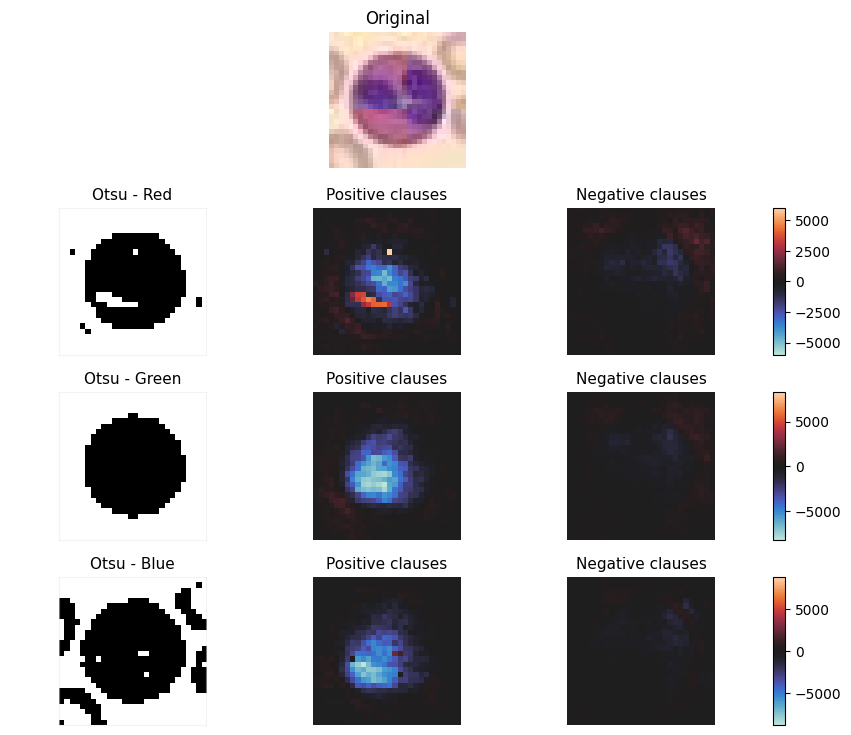

In [16]:
image_index =  1078
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 2 Local Examples 

In [17]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=2, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

2


Visualizing sample 3322  |  predicted class: 2
2026-04-10 15:54:27,008 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf7ae45c0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c2_s3322_aggr.svg


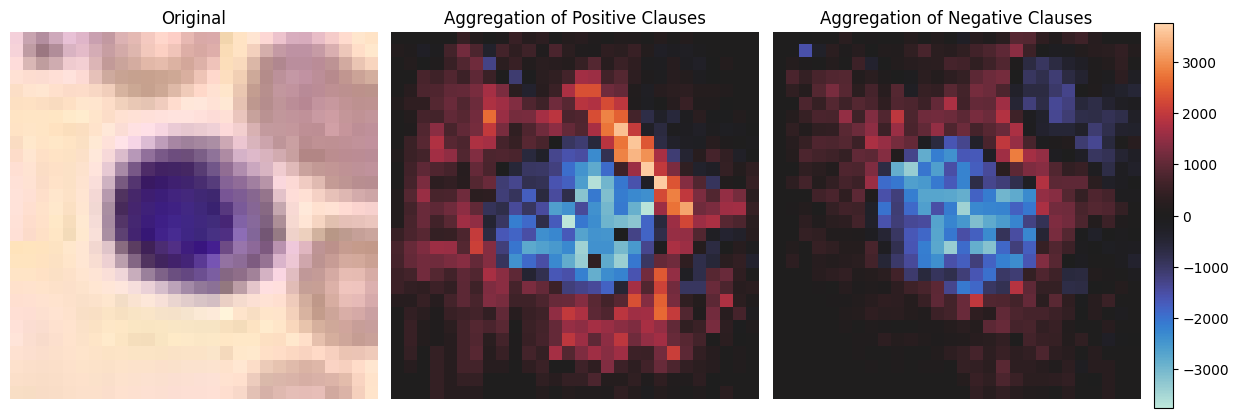

Visualizing sample 3322  |  predicted class: 2
2026-04-10 15:54:31,324 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be89e7500>
2026-04-10 15:54:31,524 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be88e3200>
2026-04-10 15:54:31,552 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be89aba10>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c2_s3322_chan.svg


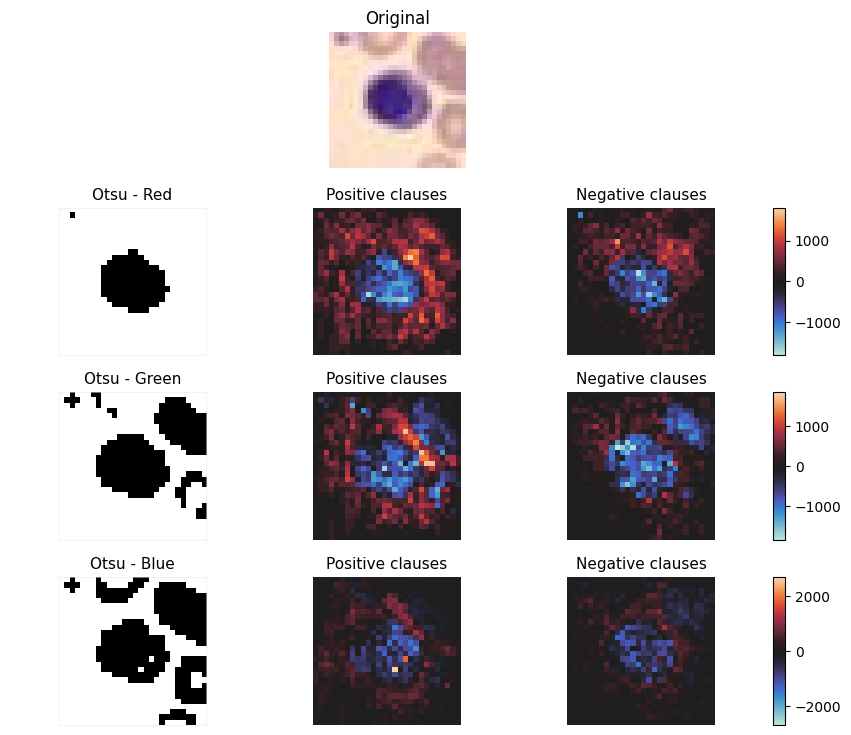

In [18]:
image_index =  3322
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

2
Visualizing sample 2356  |  predicted class: 2
2026-04-10 15:54:35,169 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be87863f0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c2_s2356_aggr.svg


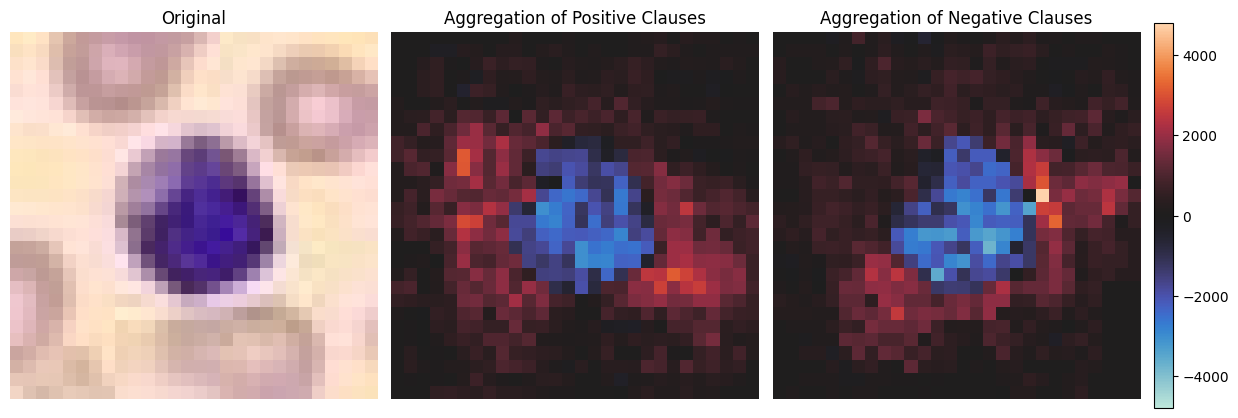

Visualizing sample 2356  |  predicted class: 2
2026-04-10 15:54:38,529 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf7c0c320>
2026-04-10 15:54:38,556 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf71ce870>
2026-04-10 15:54:38,584 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf7c37200>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c2_s2356_chan.svg


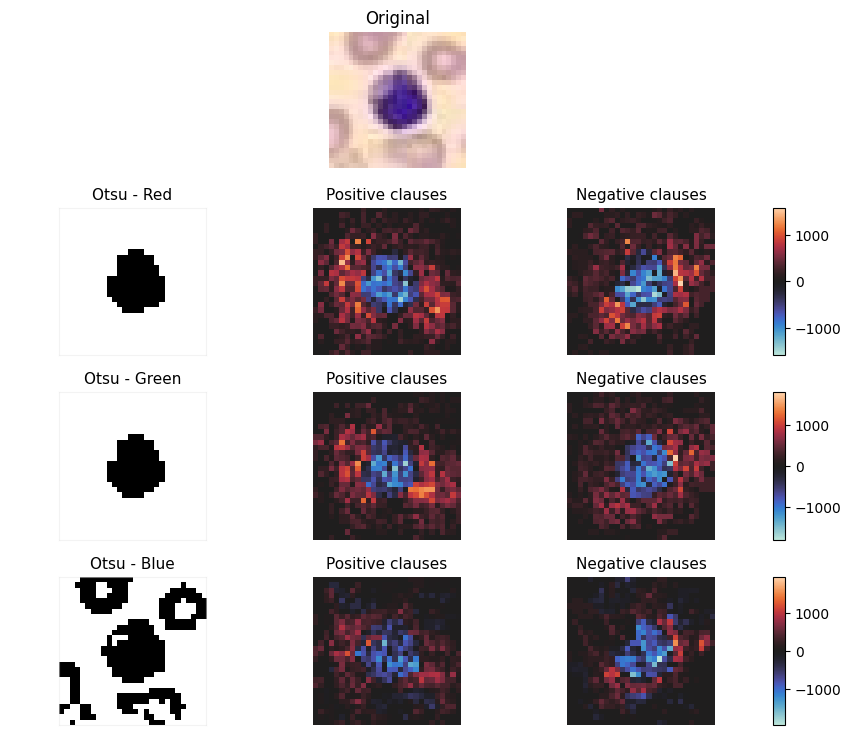

In [19]:
image_index =  2356
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

2
Visualizing sample 3215  |  predicted class: 2
2026-04-10 15:54:42,433 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc7b23c0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c2_s3215_aggr.svg


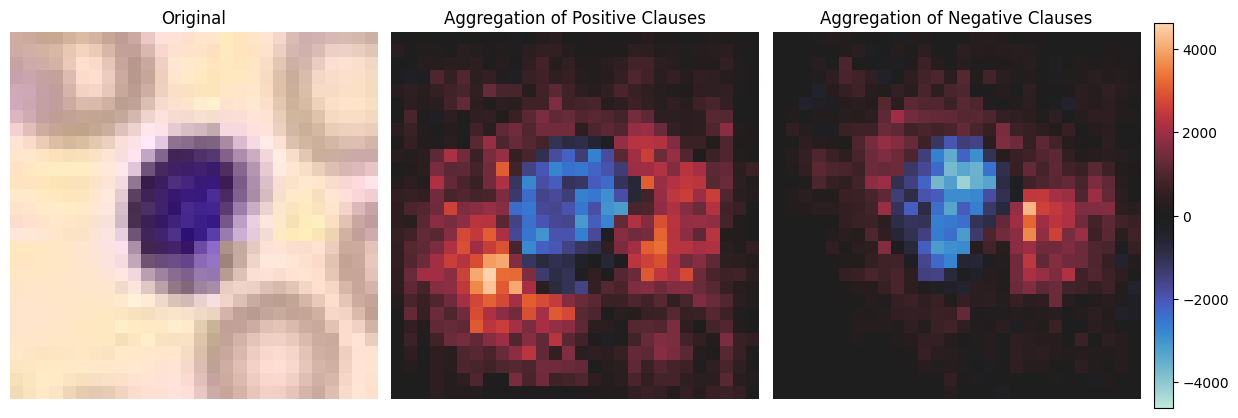

Visualizing sample 3215  |  predicted class: 2
2026-04-10 15:54:45,982 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bebabff80>
2026-04-10 15:54:46,011 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be86c68a0>
2026-04-10 15:54:46,196 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be877b500>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c2_s3215_chan.svg


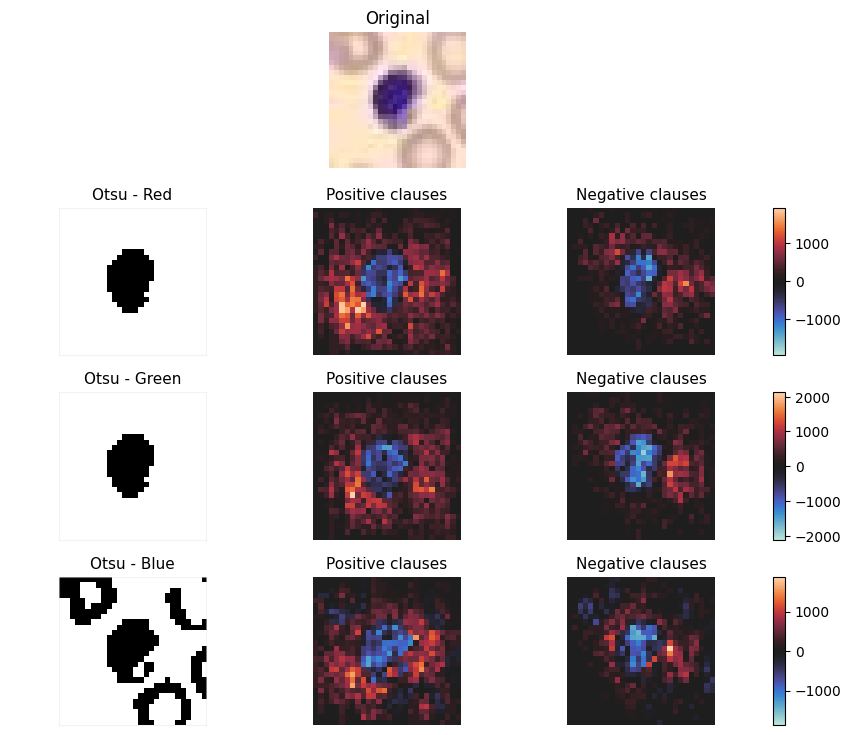

In [20]:
image_index =  3215
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 3 Local Examples 

In [21]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=3, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

3
Visualizing sample 981  |  predicted class: 3
2026-04-10 15:54:50,041 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc6ad370>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c3_s981_aggr.svg


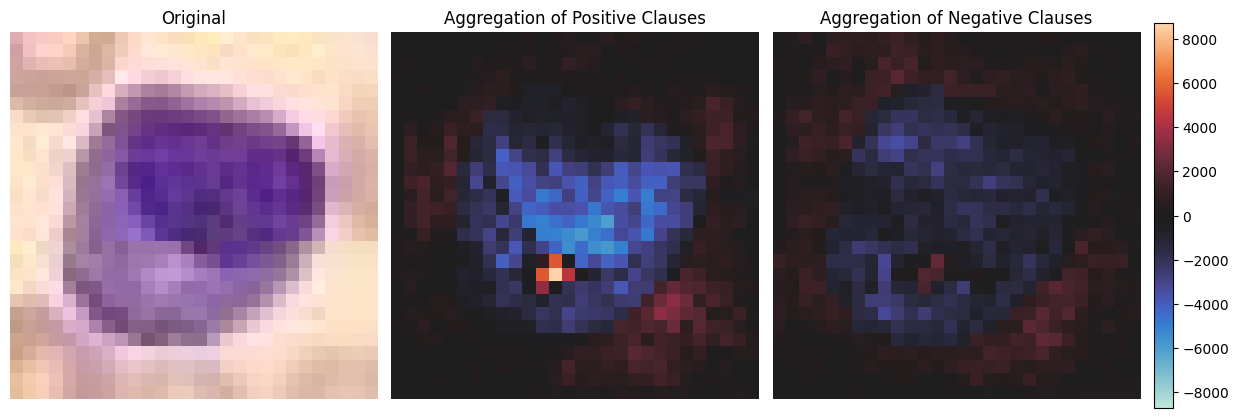

Visualizing sample 981  |  predicted class: 3
2026-04-10 15:54:53,627 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be8785f10>
2026-04-10 15:54:53,656 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf7c36570>
2026-04-10 15:54:53,685 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be8786e40>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c3_s981_chan.svg


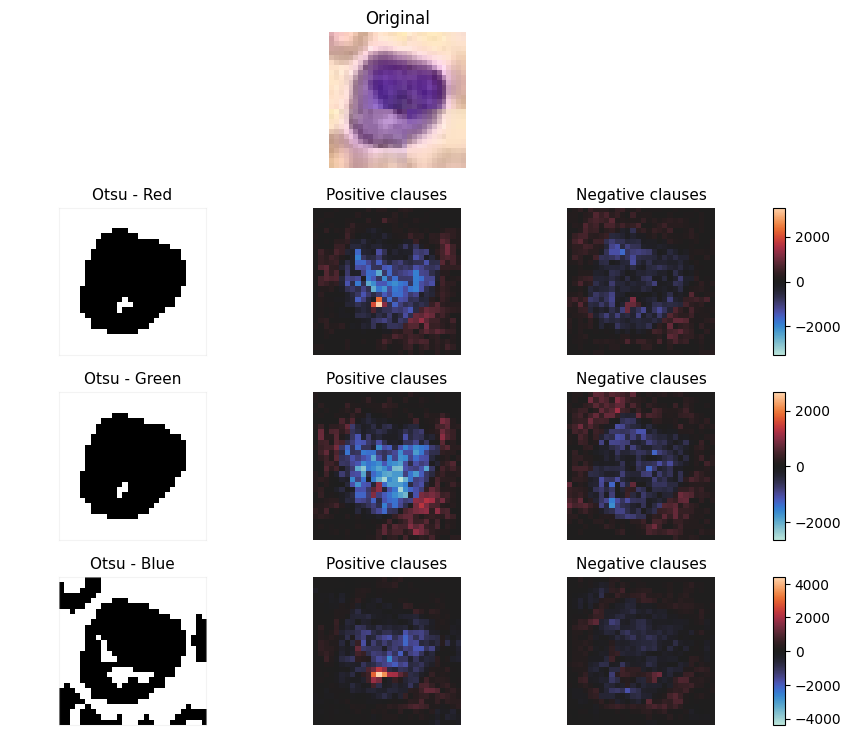

In [22]:
image_index =  981
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

3
Visualizing sample 1613  |  predicted class: 3
2026-04-10 15:54:57,520 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf70e77a0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c3_s1613_aggr.svg


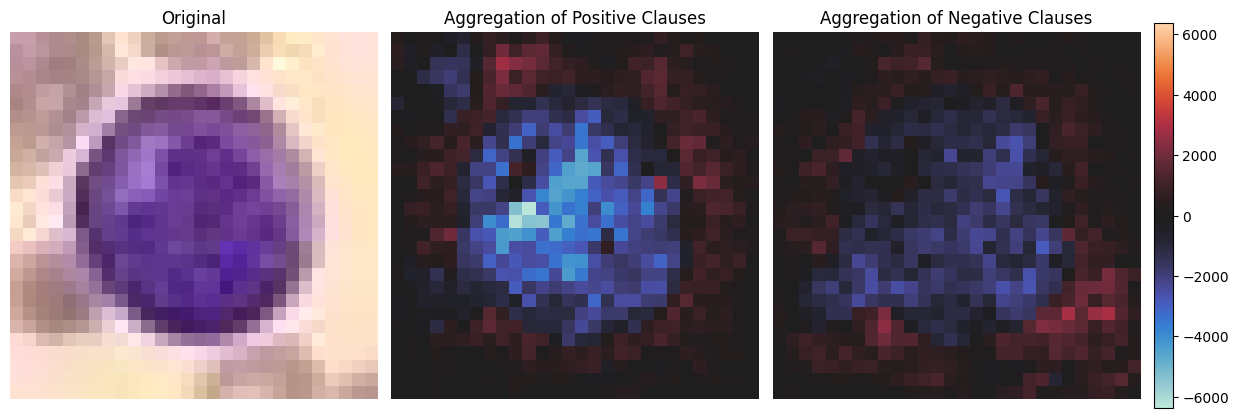

Visualizing sample 1613  |  predicted class: 3
2026-04-10 15:55:01,221 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf71e8920>
2026-04-10 15:55:01,251 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be89fa450>
2026-04-10 15:55:01,280 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be852daf0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c3_s1613_chan.svg


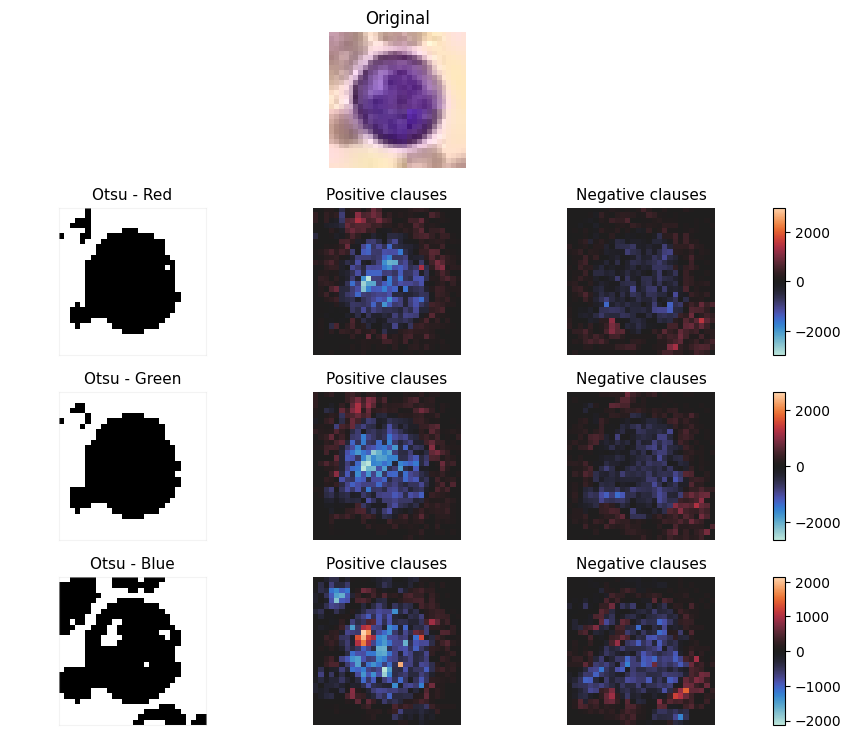

In [23]:
image_index =  1613
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

3


Visualizing sample 1603  |  predicted class: 3
2026-04-10 15:55:05,310 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bebad8620>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c3_s1603_aggr.svg


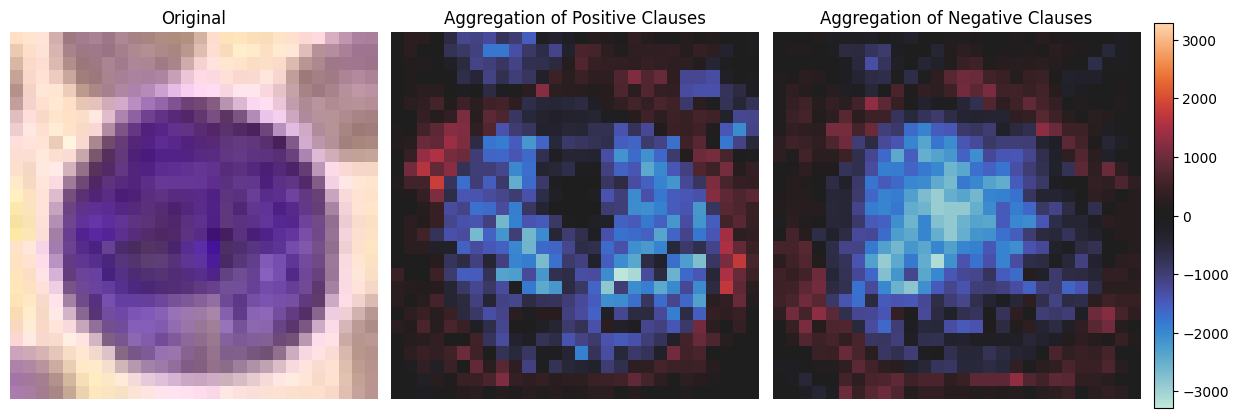

Visualizing sample 1603  |  predicted class: 3
2026-04-10 15:55:10,386 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be8556870>
2026-04-10 15:55:10,415 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be888d130>
2026-04-10 15:55:10,445 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be894ac30>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c3_s1603_chan.svg


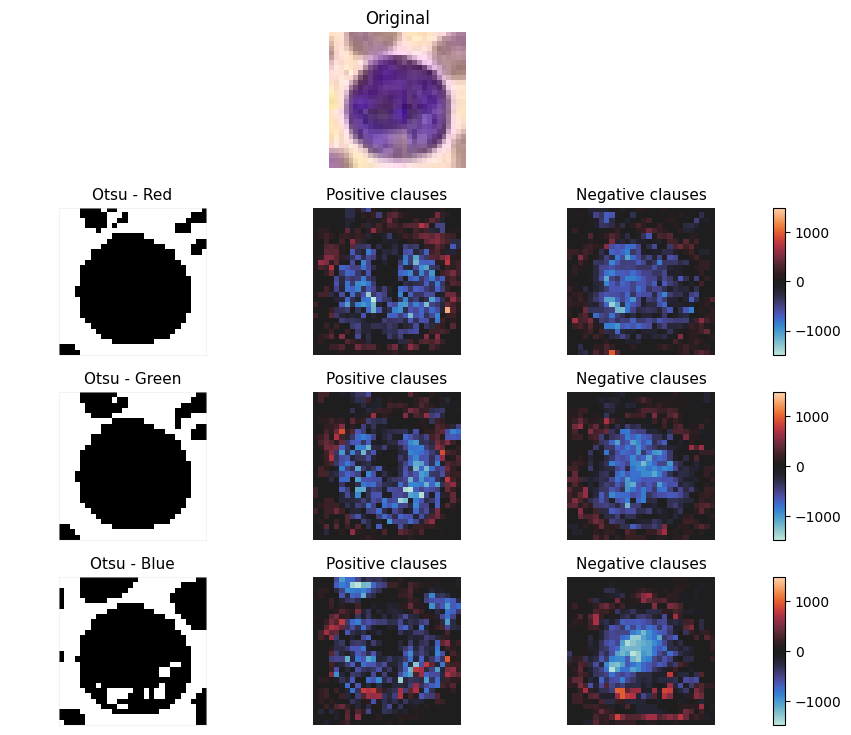

In [24]:
image_index =  1603
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 4 Local Examples 

In [25]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=4, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

4


Visualizing sample 1528  |  predicted class: 4
2026-04-10 15:55:14,312 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bebabd910>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c4_s1528_aggr.svg


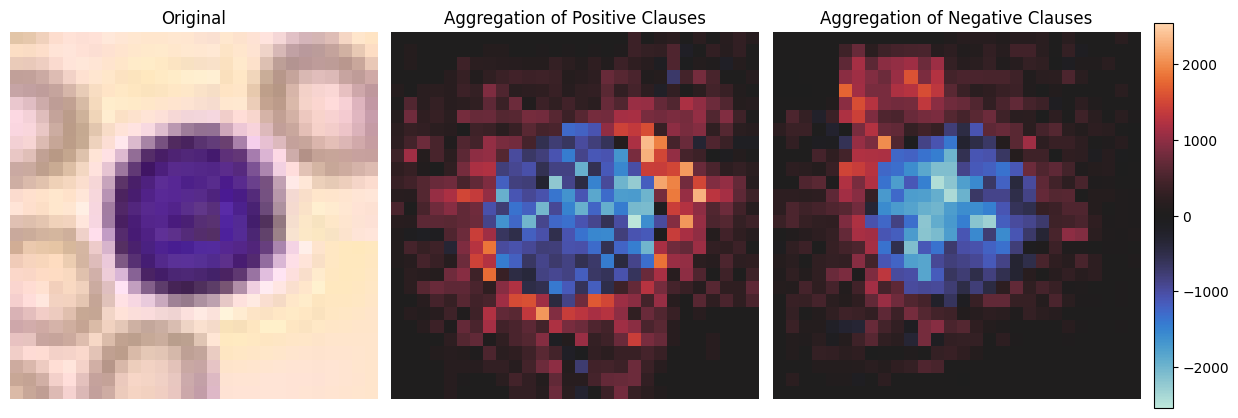

Visualizing sample 1528  |  predicted class: 4
2026-04-10 15:55:18,253 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc7b7e90>
2026-04-10 15:55:18,282 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf6fc7470>
2026-04-10 15:55:18,311 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be8750350>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c4_s1528_chan.svg


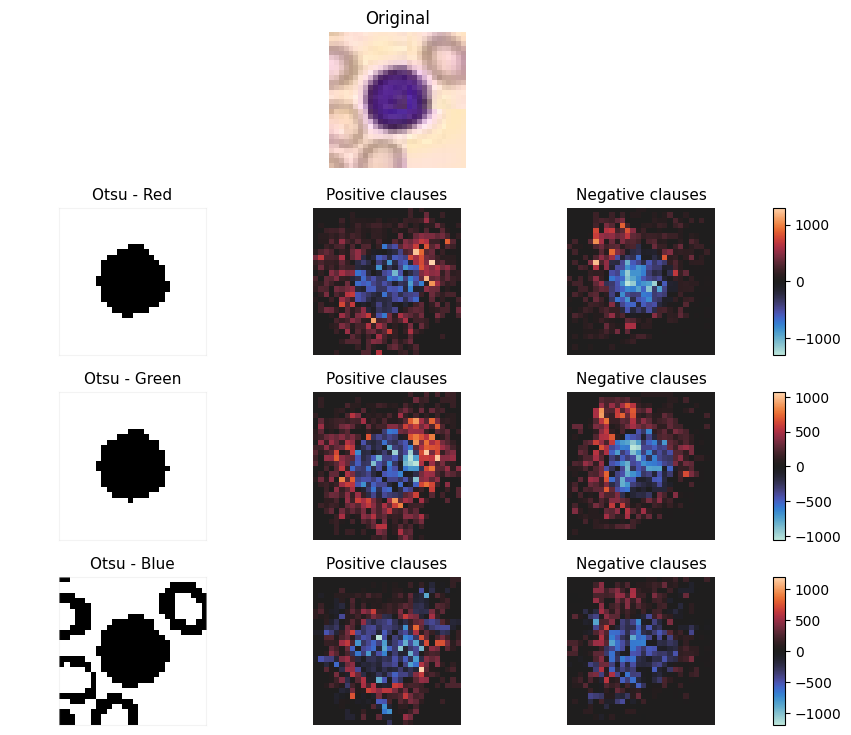

In [26]:
image_index =  1528
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

4
Visualizing sample 1294  |  predicted class: 4
2026-04-10 15:55:22,614 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be86add00>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c4_s1294_aggr.svg


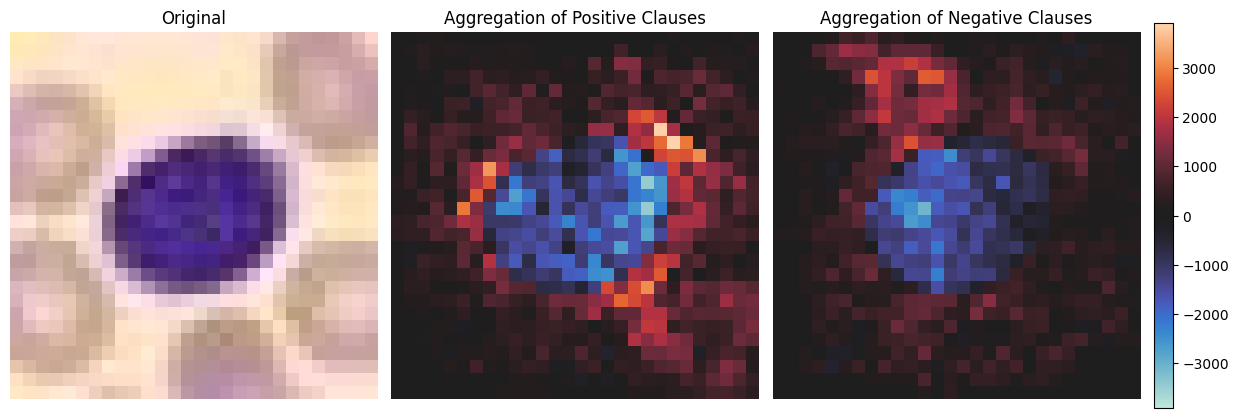

Visualizing sample 1294  |  predicted class: 4
2026-04-10 15:55:26,385 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1d64ee8050>
2026-04-10 15:55:26,414 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be89ab1d0>
2026-04-10 15:55:26,442 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be86bd580>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c4_s1294_chan.svg


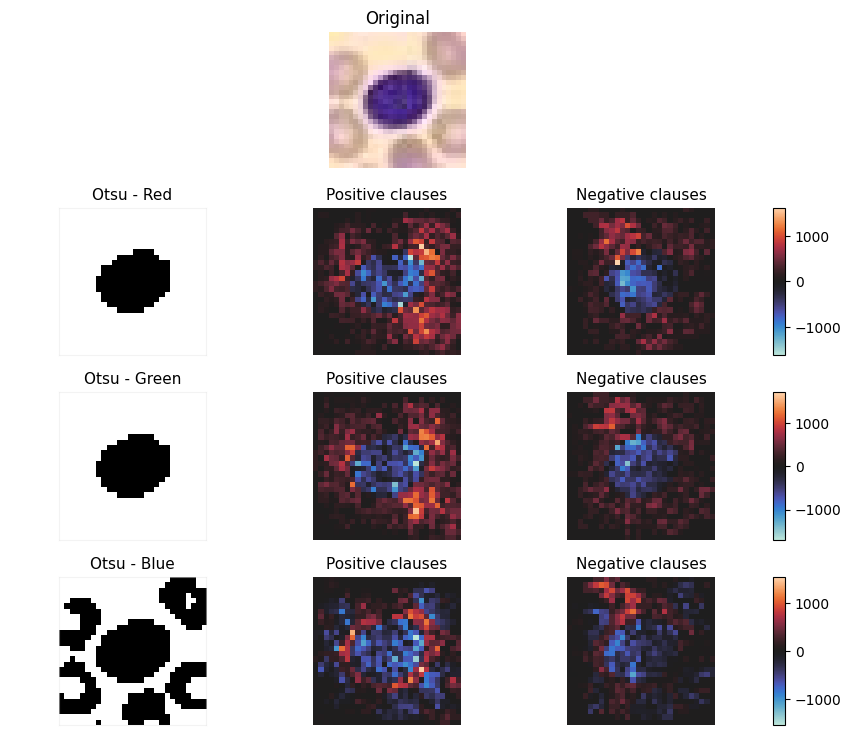

In [27]:
image_index =  1294
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

4


Visualizing sample 85  |  predicted class: 4
2026-04-10 15:55:30,555 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1beba9f410>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c4_s85_aggr.svg


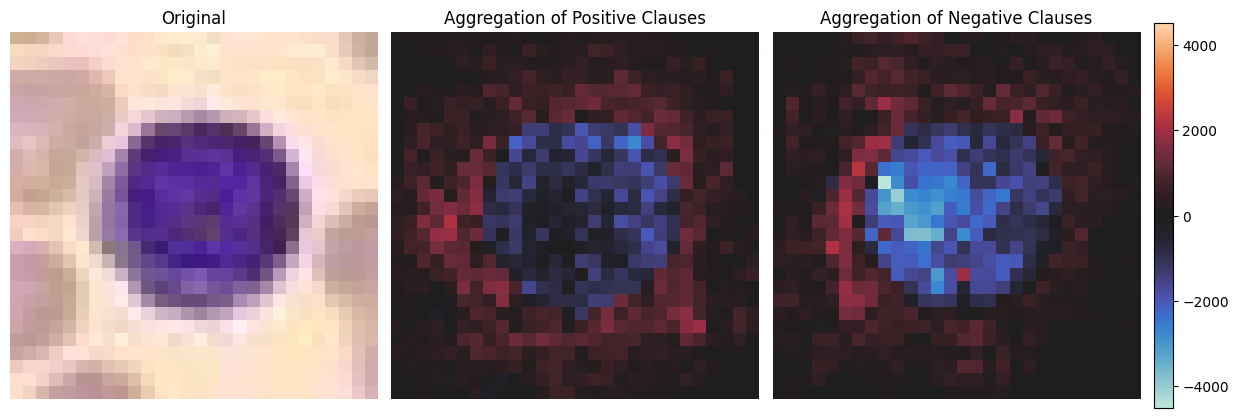

Visualizing sample 85  |  predicted class: 4
2026-04-10 15:55:34,270 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be88e4d40>
2026-04-10 15:55:34,299 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc6ae300>
2026-04-10 15:55:34,326 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be860a3f0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c4_s85_chan.svg


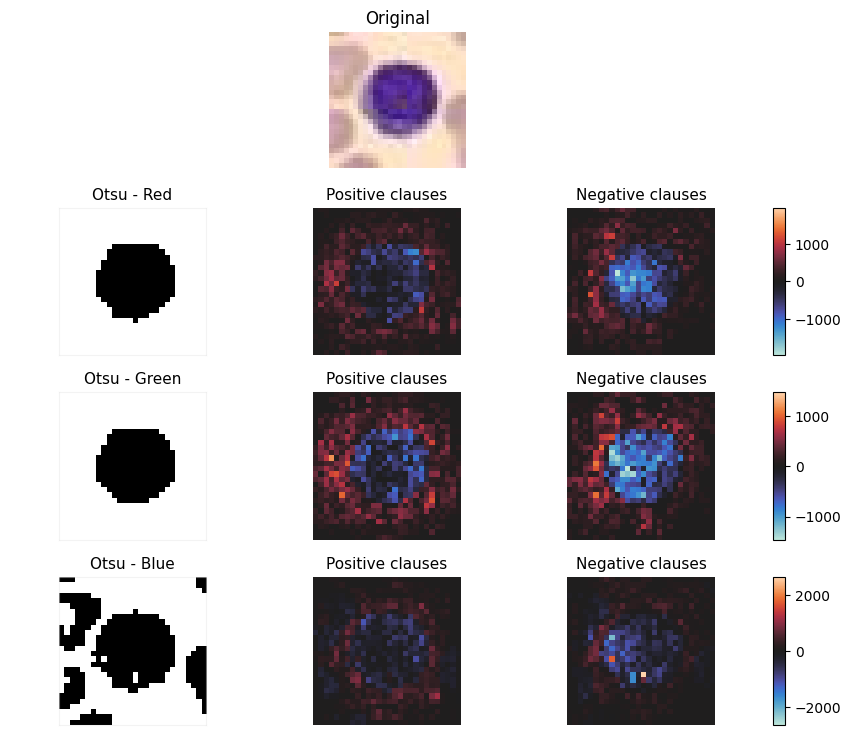

In [28]:
image_index =  85
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 5 Local Examples 

In [29]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=5, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

5
Visualizing sample 2644  |  predicted class: 5
2026-04-10 15:55:38,767 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf704a9f0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c5_s2644_aggr.svg


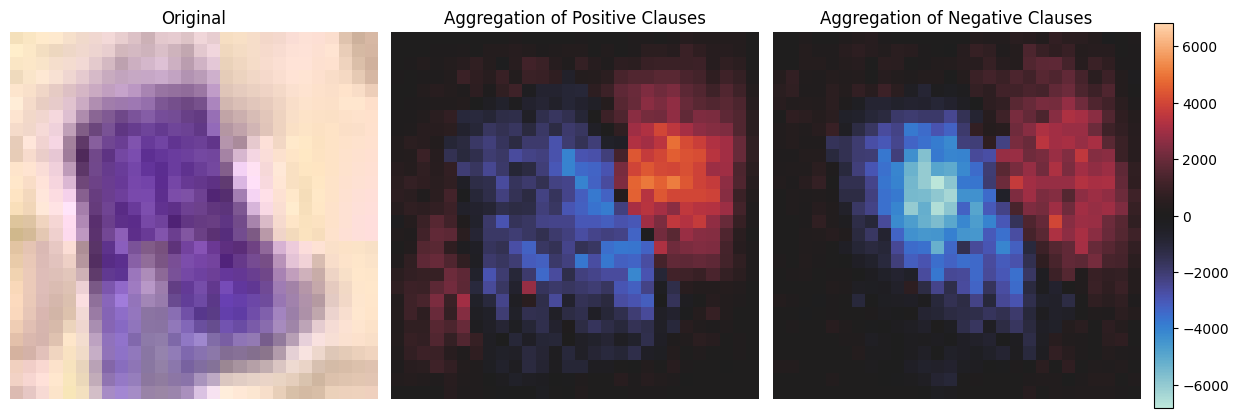

Visualizing sample 2644  |  predicted class: 5
2026-04-10 15:55:43,095 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be852fbf0>
2026-04-10 15:55:43,125 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf71cc1d0>
2026-04-10 15:55:43,152 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc807950>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c5_s2644_chan.svg


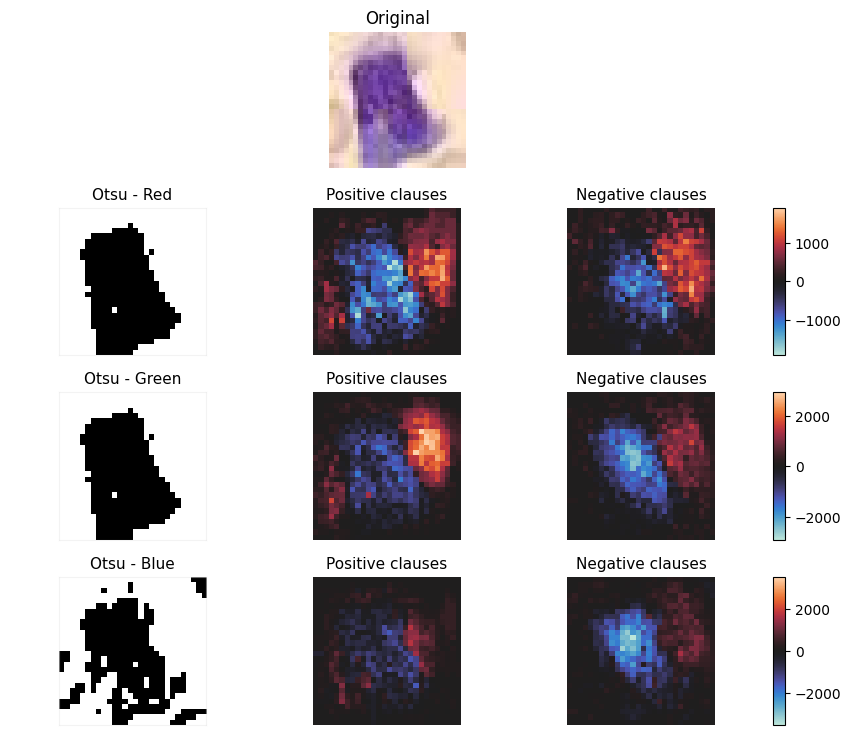

In [30]:
image_index =  2644
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

5


Visualizing sample 2090  |  predicted class: 5
2026-04-10 15:55:47,336 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1beba9f260>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c5_s2090_aggr.svg


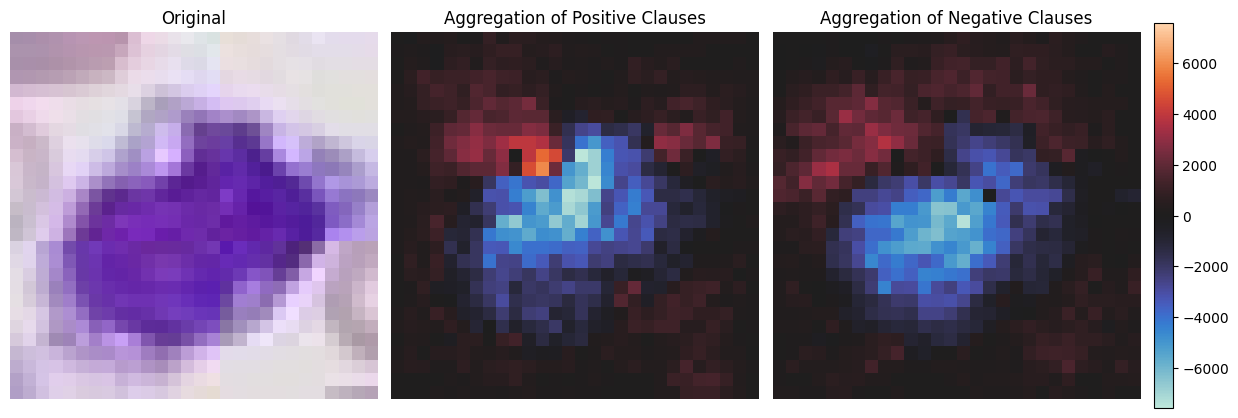

Visualizing sample 2090  |  predicted class: 5
2026-04-10 15:55:51,390 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc7fb710>
2026-04-10 15:55:51,419 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc6b7f80>
2026-04-10 15:55:51,447 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf7aba030>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c5_s2090_chan.svg


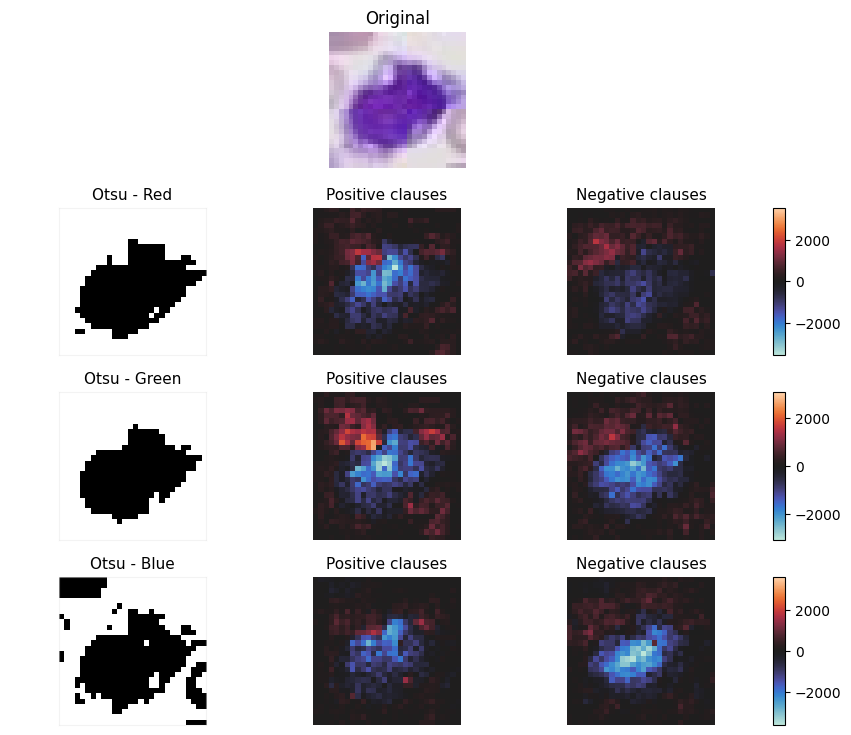

In [31]:
image_index =  2090
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

5
Visualizing sample 418  |  predicted class: 5
2026-04-10 15:55:55,843 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be862e7b0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c5_s418_aggr.svg


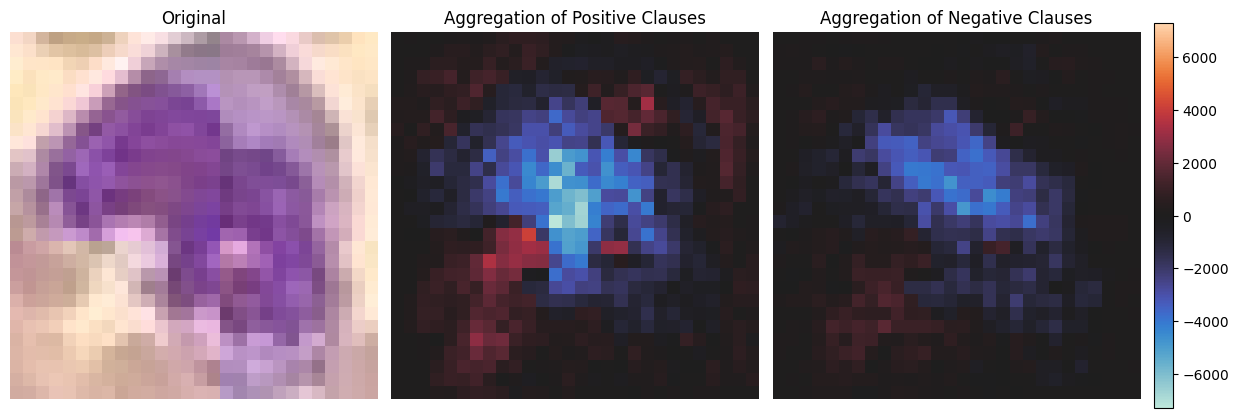

Visualizing sample 418  |  predicted class: 5
2026-04-10 15:56:00,425 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1beba71e50>
2026-04-10 15:56:00,453 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be886a300>
2026-04-10 15:56:00,482 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf728b5f0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c5_s418_chan.svg


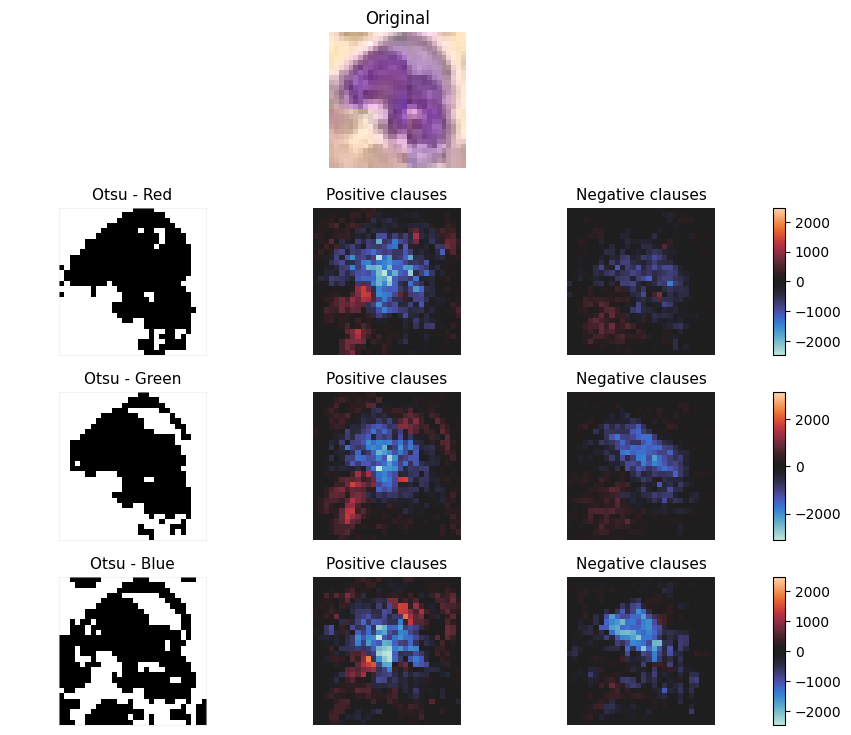

In [32]:
image_index =  418
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 6 Local Examples 

In [33]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=6, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

6
Visualizing sample 232  |  predicted class: 6
2026-04-10 15:56:05,560 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be86f0bc0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c6_s232_aggr.svg


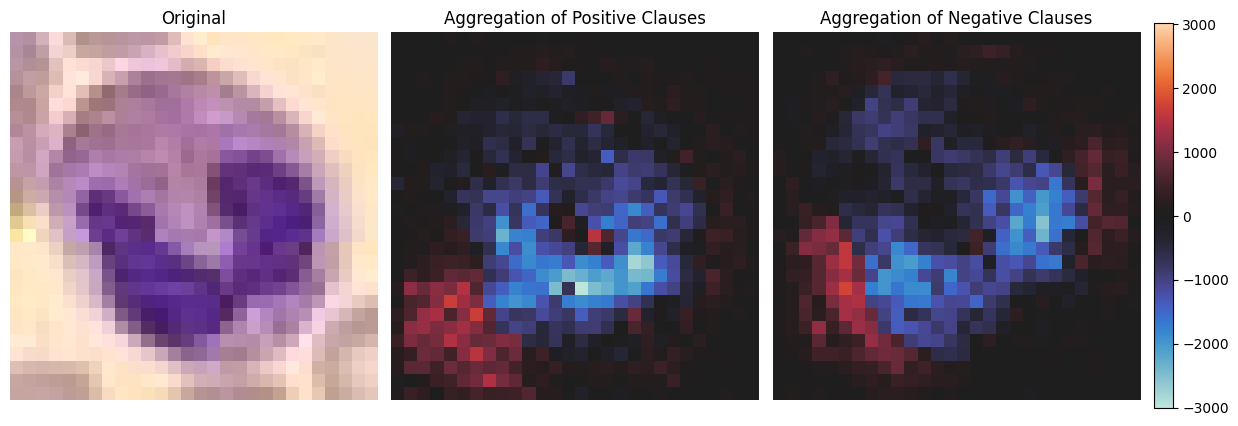

Visualizing sample 232  |  predicted class: 6
2026-04-10 15:56:09,382 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf7ab8560>
2026-04-10 15:56:09,410 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be88a85f0>
2026-04-10 15:56:09,439 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be87f30b0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c6_s232_chan.svg


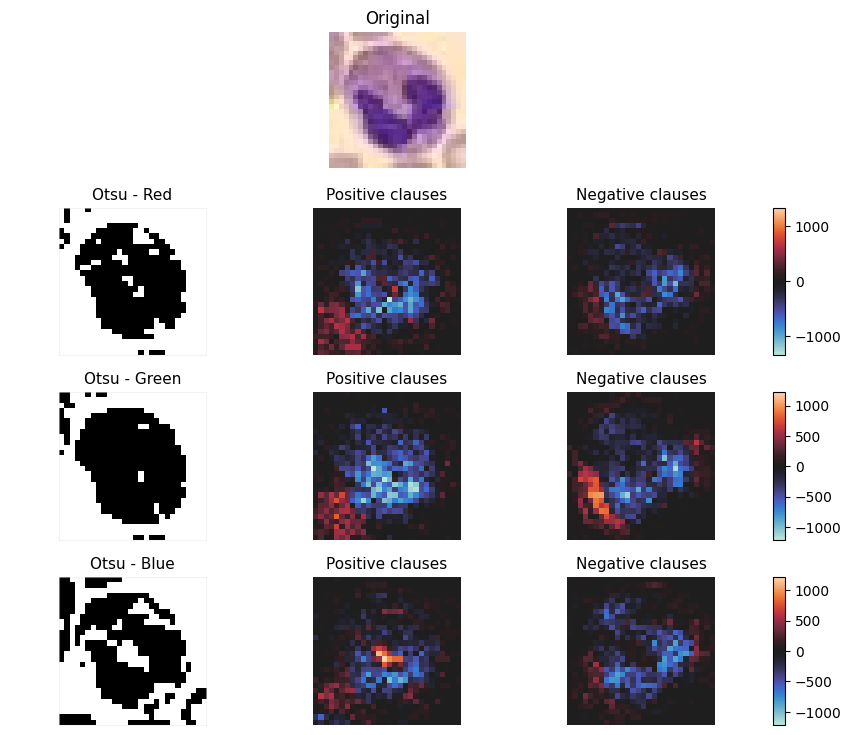

In [34]:
image_index =  232
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

6
Visualizing sample 1822  |  predicted class: 6
2026-04-10 15:56:13,076 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bfc80aed0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c6_s1822_aggr.svg


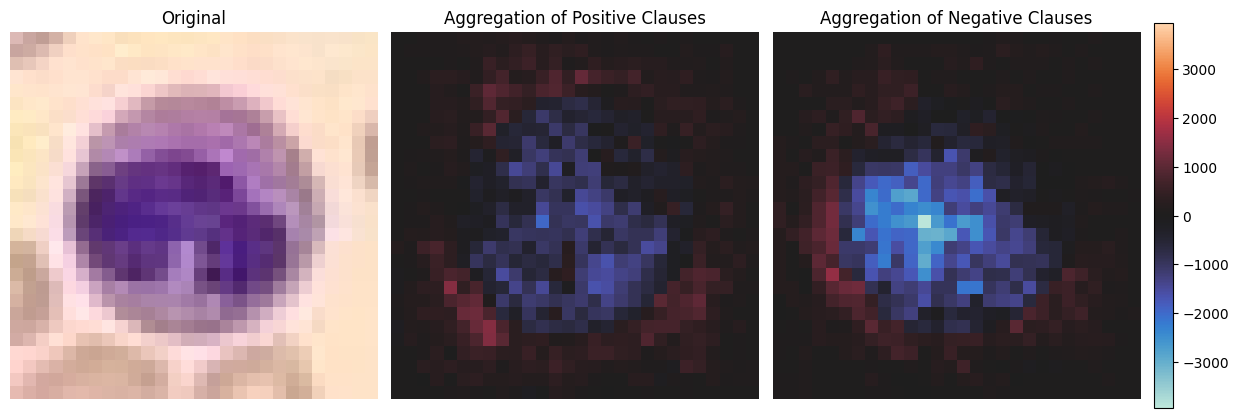

Visualizing sample 1822  |  predicted class: 6
2026-04-10 15:56:16,574 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf7afac60>
2026-04-10 15:56:16,602 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1beba20e30>
2026-04-10 15:56:16,628 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be86f3c20>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c6_s1822_chan.svg


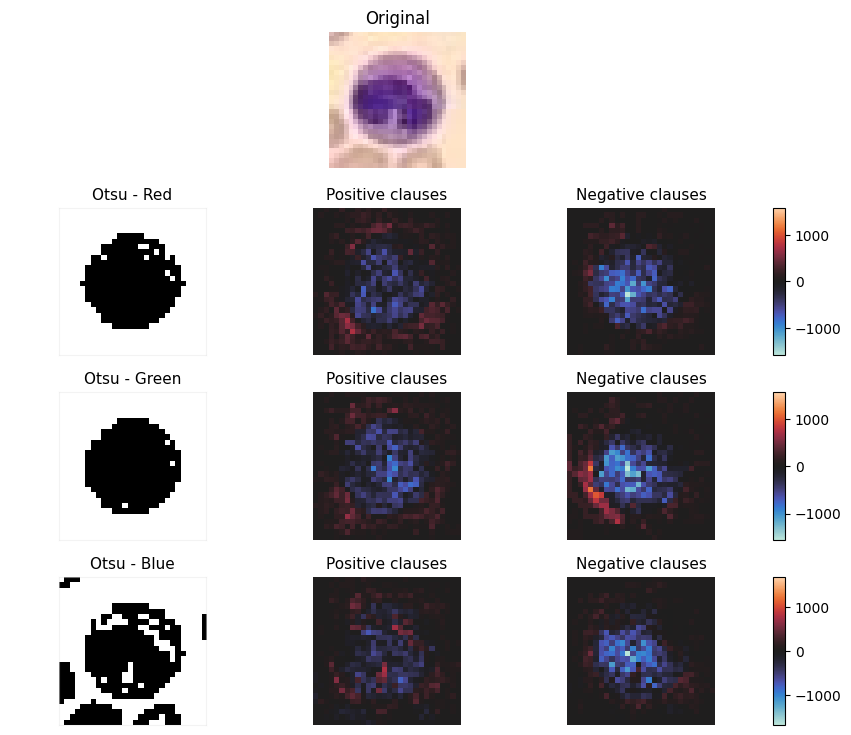

In [35]:
image_index =  1822
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

6
Visualizing sample 1686  |  predicted class: 6
2026-04-10 15:56:20,403 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf70e8680>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c6_s1686_aggr.svg


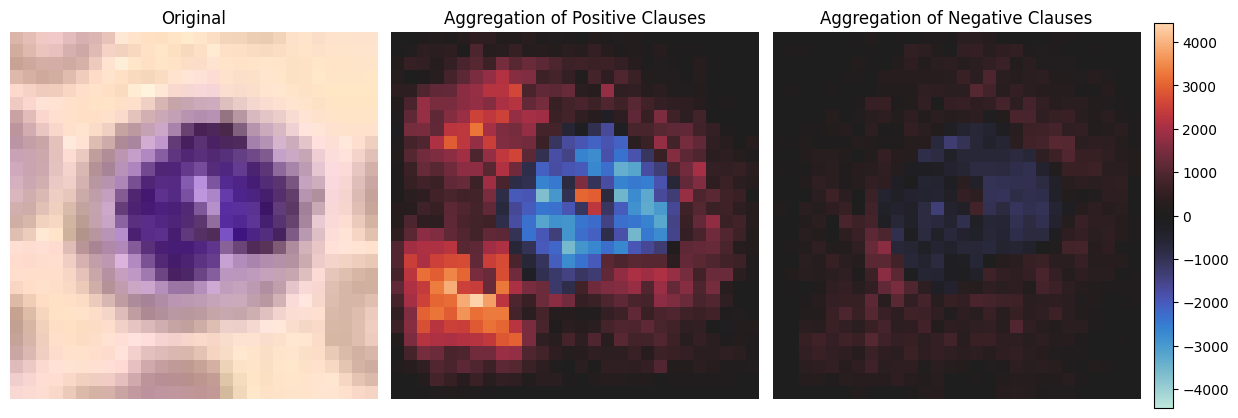

Visualizing sample 1686  |  predicted class: 6
2026-04-10 15:56:24,394 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1be87f0950>
2026-04-10 15:56:24,425 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf6fc4560>
2026-04-10 15:56:24,458 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7b1bf70e4f50>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c6_s1686_chan.svg


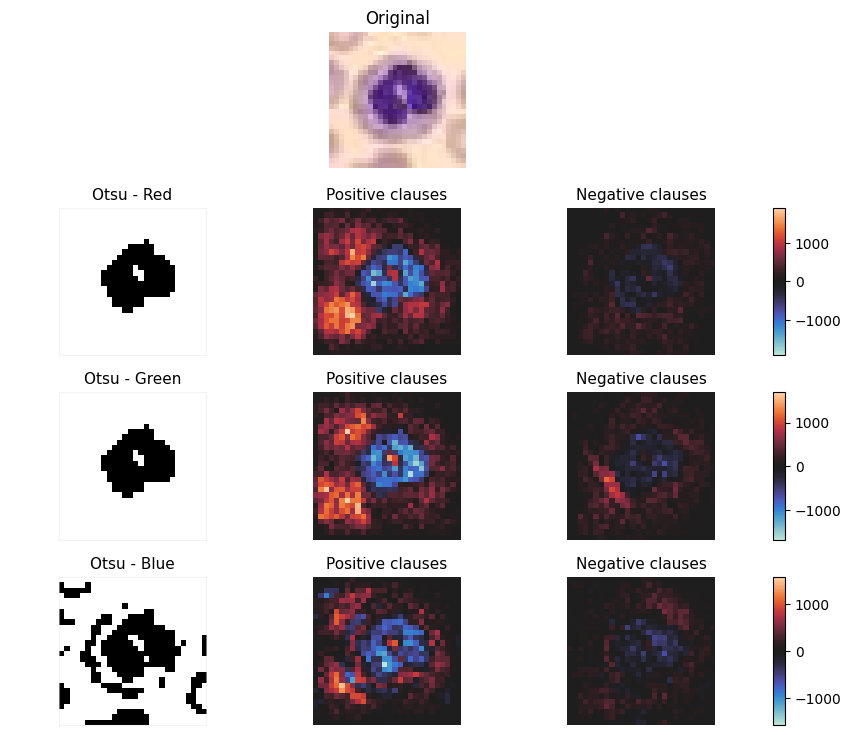

In [36]:
image_index =  1686
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Class 7 Local Examples 

In [ ]:
# for i in range(3): 
#     print("============================================")
#     image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=7, random=True)
#     print(f"Selected image index: {image_index}")
#     print(f"True class: {Y_test[image_index]}")
#     print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 1165
True class: 7
Predicted class: 7
Selected image index: 1346
True class: 7
Predicted class: 7
Selected image index: 2318
True class: 7
Predicted class: 7


7
2026-04-11 19:11:26,311 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-11 19:11:26,315 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 1165  |  predicted class: 7
2026-04-11 19:11:26,352 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6c26a5130>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c7_s1165_aggr.svg


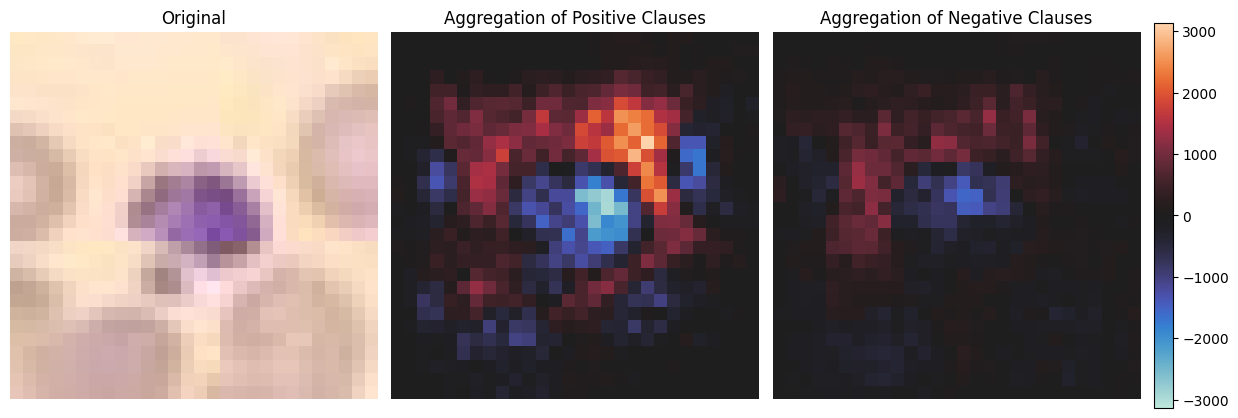

Visualizing sample 1165  |  predicted class: 7
2026-04-11 19:11:30,415 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6c26cca70>
2026-04-11 19:11:30,444 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6c25acb90>
2026-04-11 19:11:30,471 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6bdb3c2c0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c7_s1165_chan.svg


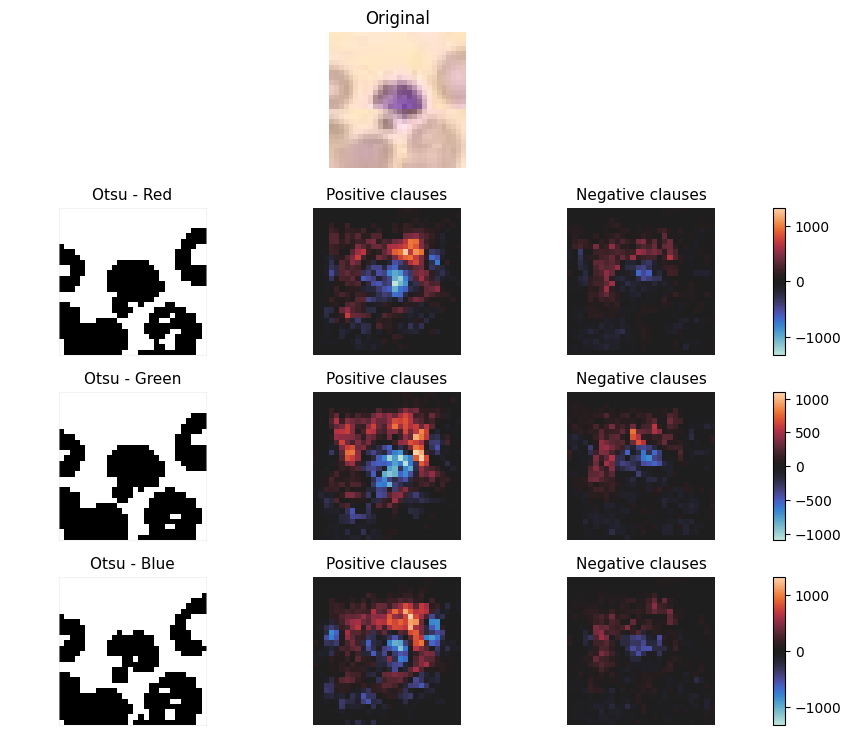

In [11]:
image_index =  1165
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

7
Visualizing sample 1346  |  predicted class: 7
2026-04-11 19:11:34,792 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6bda6b650>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c7_s1346_aggr.svg


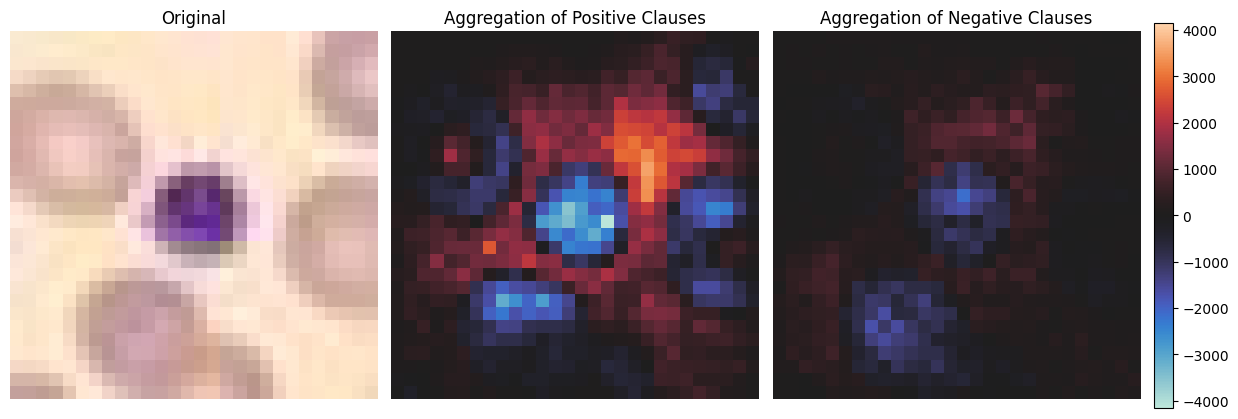

Visualizing sample 1346  |  predicted class: 7
2026-04-11 19:11:38,844 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6c25bc110>
2026-04-11 19:11:38,874 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6bcef6b70>
2026-04-11 19:11:38,902 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6ae9346b0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c7_s1346_chan.svg


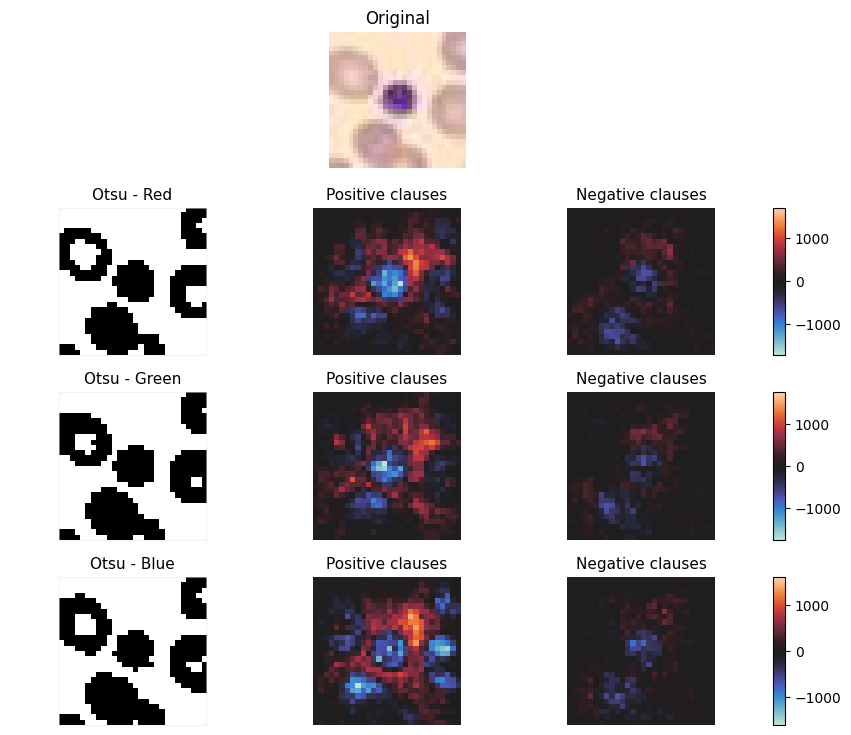

In [12]:
image_index =  1346
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

7
Visualizing sample 2318  |  predicted class: 7
2026-04-11 19:11:47,531 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6bcef5790>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c7_s2318_aggr.svg


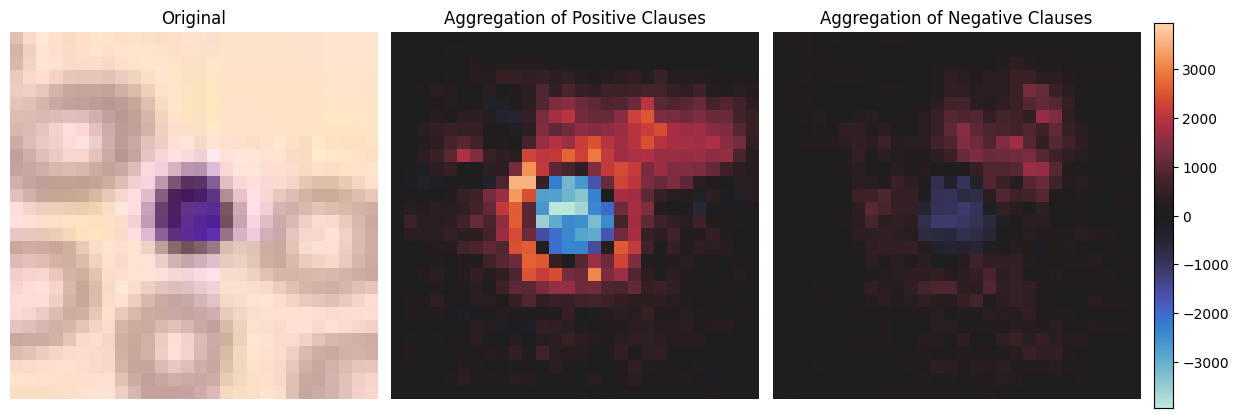

Visualizing sample 2318  |  predicted class: 7
2026-04-11 19:11:51,525 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6ae830140>
2026-04-11 19:11:51,558 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6ae8f1e50>
2026-04-11 19:11:51,598 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7bd6ae7401a0>
Saved to saved_heatmaps/otsu/blood_otsu_lh_c7_s2318_chan.svg


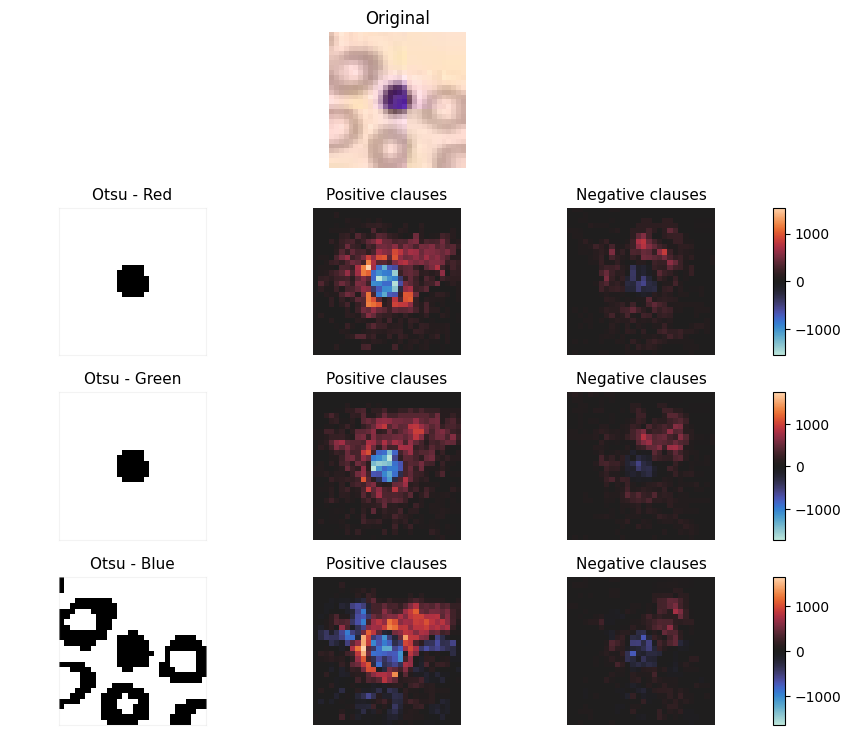

In [13]:
image_index =  2318
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=channel_names, save_path=save_path_per_channel)

# Global Heatmap 0

In [38]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 0

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:46:19,598 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:46:19,601 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 19:46:19,624 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76886c17f590>
Saved to saved_heatmaps/otsu/blood_otsu_gh_c0.svg


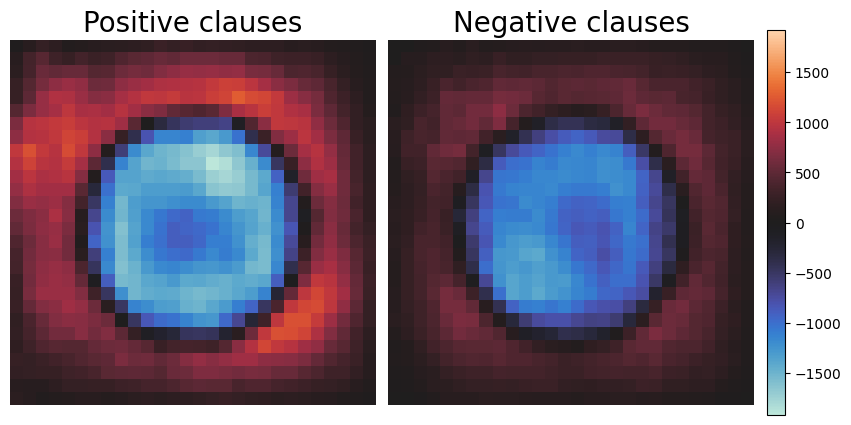

pos shape: (28, 28), min: -1921.05, max: 1270.35
neg shape: (28, 28), min: -1420.85, max: 748.85
saved_heatmaps/otsu/blood_otsu_gh_c0.svg


In [6]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 1

In [7]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 1

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:46:20,158 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76886c20bb00>
Saved to saved_heatmaps/otsu/blood_otsu_gh_c1.svg


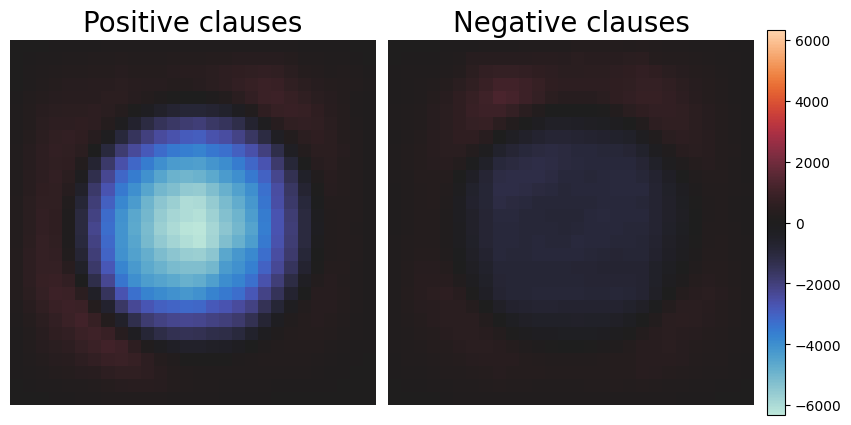

pos shape: (28, 28), min: -6322.92, max: 1039.22
neg shape: (28, 28), min: -1227.24, max: 1251.78
saved_heatmaps/otsu/blood_otsu_gh_c1.svg


In [8]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 2

In [9]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 2

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:46:20,655 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76884ec978c0>
Saved to saved_heatmaps/otsu/blood_otsu_gh_c2.svg


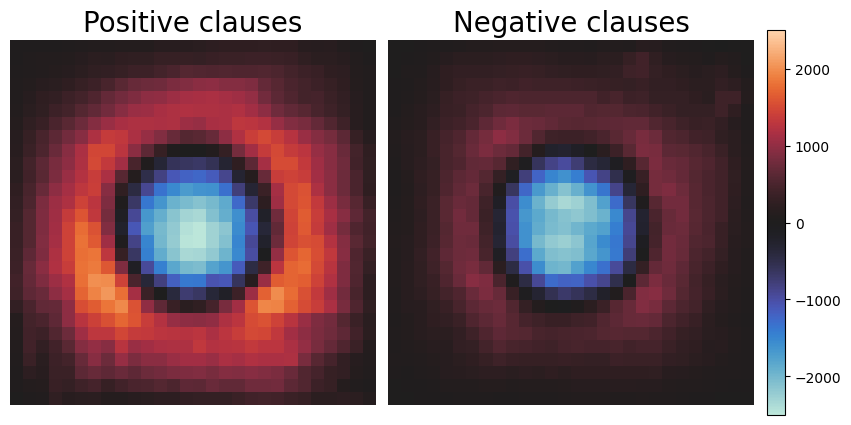

pos shape: (28, 28), min: -2501.72, max: 2058.73
neg shape: (28, 28), min: -2354.67, max: 959.58
saved_heatmaps/otsu/blood_otsu_gh_c2.svg


In [10]:
target_class = 2
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 3

In [11]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 3

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:46:21,041 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76886c080c20>
Saved to saved_heatmaps/otsu/blood_otsu_gh_c3.svg


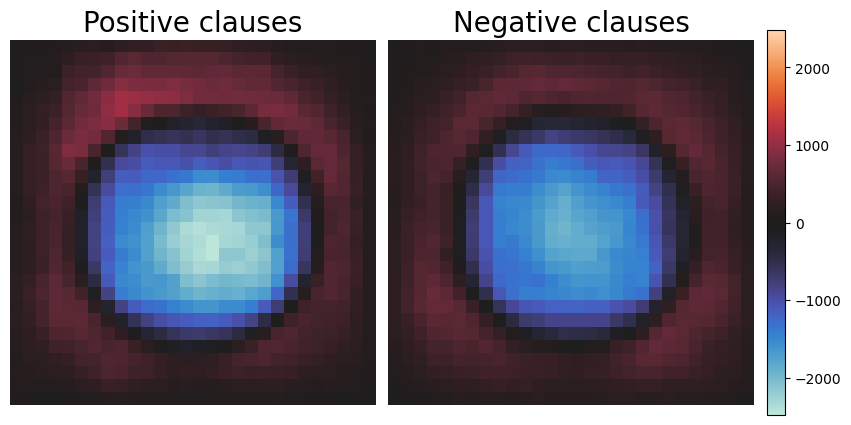

pos shape: (28, 28), min: -2482.12, max: 1102.70
neg shape: (28, 28), min: -1975.33, max: 701.30
saved_heatmaps/otsu/blood_otsu_gh_c3.svg


In [12]:
target_class = 3
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 4

In [13]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 4

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:46:21,420 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76886cda2e40>


Saved to saved_heatmaps/otsu/blood_otsu_gh_c4.svg


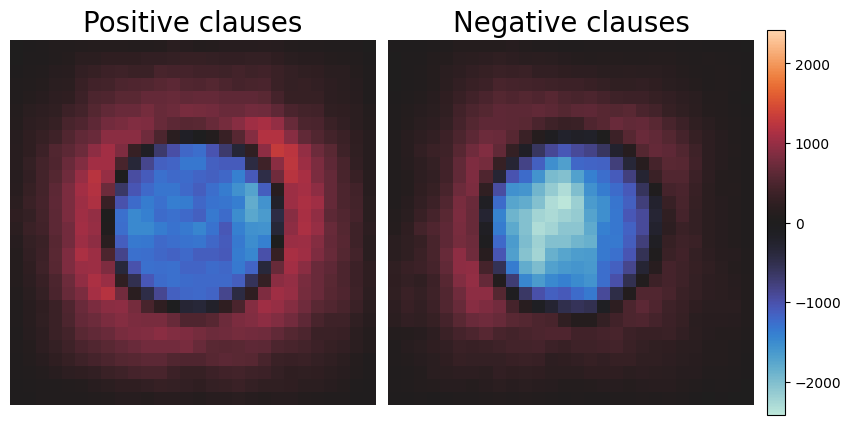

pos shape: (28, 28), min: -1820.41, max: 1306.76
neg shape: (28, 28), min: -2418.29, max: 978.23
saved_heatmaps/otsu/blood_otsu_gh_c4.svg


In [14]:
target_class = 4
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 5

In [15]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 5

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:46:21,808 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x768845eb2c90>


Saved to saved_heatmaps/otsu/blood_otsu_gh_c5.svg


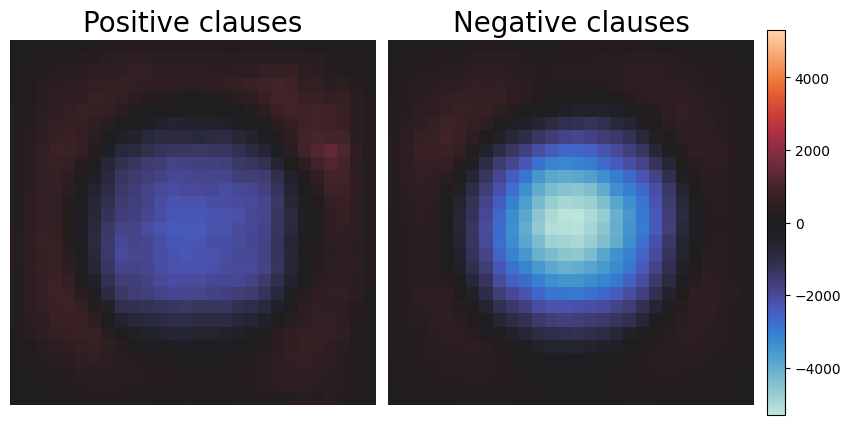

pos shape: (28, 28), min: -2389.40, max: 1418.09
neg shape: (28, 28), min: -5303.27, max: 894.84
saved_heatmaps/otsu/blood_otsu_gh_c5.svg


In [16]:
target_class = 5
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 6

In [17]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 6

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:46:22,207 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x768843d7c7d0>
Saved to saved_heatmaps/otsu/blood_otsu_gh_c6.svg


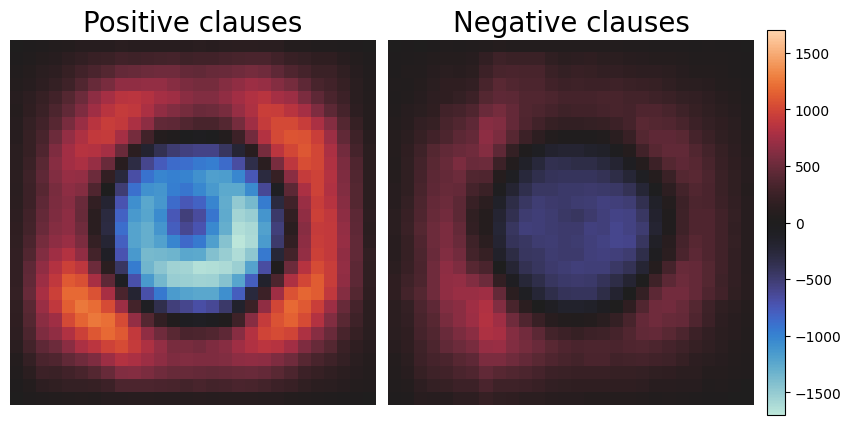

pos shape: (28, 28), min: -1700.57, max: 1255.69
neg shape: (28, 28), min: -606.30, max: 830.96
saved_heatmaps/otsu/blood_otsu_gh_c6.svg


In [18]:
target_class = 6
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)

# Global Heatmap 7

In [19]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 7

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 19:46:22,618 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x768843c347d0>
Saved to saved_heatmaps/otsu/blood_otsu_gh_c7.svg


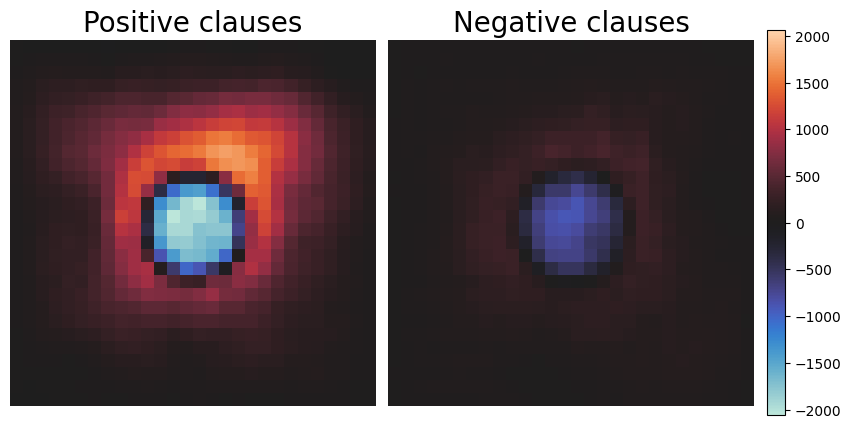

pos shape: (28, 28), min: -2060.62, max: 1747.42
neg shape: (28, 28), min: -904.20, max: 391.40
saved_heatmaps/otsu/blood_otsu_gh_c7.svg


In [20]:
target_class = 7
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG, bigger_font = True)
print(save_path_global)